# Paper Figures: When Not to Estimate

4-page paper figure generation. 3 configs: ELAA 15GHz, ELAA 28GHz, 5G MIMO 3.5GHz.

**Logic flow:**
1. Fig 2: Channel varies slowly → skip is feasible
2. Fig 3: Skipping at noise floor level doesn't hurt NMSE
3. Fig 4: LS delta is practical best feature for scheduling
4. Fig 5: Path diversity determines skip feasibility (not speed alone)

In [1]:
import os, sys
sys.path.insert(0, "../..")
os.environ["CUDA_VISIBLE_DEVICES"] = "3,4,5,6,7"

from src.experiments.result_cache import cached
import json, numpy as np, matplotlib.pyplot as plt, torch
from tqdm.auto import tqdm
from src.experiments.pipeline import (
    load_all_ues, _precompute_deltas, _vectorized_scheduling, 
    _compute_nmse_from_tiers, _compute_nmse_from_alphas, _batch_nmse_multi_tau, SPEED_LABELS
)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 10, "figure.dpi": 150})

# ── Reproducibility ──
np.random.seed(42)
torch.manual_seed(42)

# ══════════════════════════════════════════════════════════════
#  SSOT: All configurable constants in one place
# ══════════════════════════════════════════════════════════════
SNR_DB = 20.0
NOISE_FLOOR = np.sqrt(2.0 / (10 ** (SNR_DB / 10)))  # ≈ 0.141

PRESETS = ["munich_elaa_m_1k_15g", "munich_elaa_m_1k_28g"]
PRESET_LABELS = {"munich_elaa_m_1k_15g": "ELAA 15GHz", "munich_elaa_m_1k_28g": "ELAA 28GHz"}
MAX_SNAPSHOTS = 800
UE_PER_SPEED = 3

# ── Load data + precompute ──
all_ue_data = {}
for preset in PRESETS:
    try:
        ud = load_all_ues(preset, max_snapshots=MAX_SNAPSHOTS, ue_per_speed=UE_PER_SPEED)
        for u in ud["ue_list"]:
            h_ls, d_ls, d_oracle, nmse_reuse = _precompute_deltas(u["h_real"], SNR_DB)
            u["h_ls"] = h_ls
            u["d_ls"] = d_ls
            u["d_oracle"] = d_oracle
        all_ue_data[preset] = ud
        print(f"  {PRESET_LABELS[preset]}: {len(ud['ue_list'])} UEs, {ud['max_snapshots']} snaps")
    except Exception as e:
        print(f"  {PRESET_LABELS[preset]}: FAILED ({e})")
        all_ue_data[preset] = None

# ── Derive speed groups from loaded data (SSOT) ──
_all_speeds = sorted({round(u["speed"], 1)
                       for ud in all_ue_data.values() if ud
                       for u in ud["ue_list"]})
SPEED_ORDER = [str(s) for s in _all_speeds]  # ["0.0", "1.0", ...]
_CMAP = plt.cm.coolwarm(np.linspace(0.1, 0.9, max(len(_all_speeds), 1)))
SPEED_COLORS = {str(s): _CMAP[i] for i, s in enumerate(_all_speeds)}

def speed_label(speed):
    return str(round(speed, 1))

def group_by_speed(ue_list):
    groups = {s: [] for s in SPEED_ORDER}
    for u in ue_list:
        lbl = speed_label(u["speed"])
        groups.setdefault(lbl, []).append(u)
    return groups

# Tag each UE with speed label
for ud in all_ue_data.values():
    if ud:
        for u in ud["ue_list"]:
            u["spd"] = speed_label(u["speed"])

print(f"\nLoaded: {sum(1 for v in all_ue_data.values() if v is not None)}/{len(PRESETS)} configs")
print(f"Speeds: {SPEED_ORDER} ({len(_all_speeds)} groups)")

# ── Coherence time per (preset, speed) ──
c_light = 3e8
COHERENCE = {}  # {preset: {speed_str: T_c_slots}}
for preset in PRESETS:
    ud = all_ue_data.get(preset)
    if ud is None: continue
    cfg = ud["cfg"]
    lam = c_light / cfg.frequency
    slot_s = cfg.slot_duration_s
    coh = {}
    for s in _all_speeds:
        if s < 0.01:
            coh[str(s)] = float("inf")
        else:
            T_c = lam / (2 * s)  # Clarke's coherence time (s)
            coh[str(s)] = T_c / slot_s  # in slots
    COHERENCE[preset] = coh
    f_ghz = cfg.frequency / 1e9
    print(f"  {PRESET_LABELS[preset]} ({f_ghz:.0f}GHz, λ={lam*1e3:.1f}mm): "
          + ", ".join(f"{k}m/s→{v:.1f}slots" for k, v in coh.items() if v < 1e6))
print(f"RAM: {sum(sum(u['h_real'].nbytes for u in ud['ue_list']) for ud in all_ue_data.values() if ud)/1e9:.1f} GB")

# ── Precompute shared τ sweeps (reused by Fig 3, 7, 8) ──
TAU_VALUES = np.linspace(0.005, 0.5, 40).tolist()       # Fig 7, 8 (d_ls)
TAU_ORACLE = np.linspace(0.001, 0.3, 25).tolist()       # Fig 3 (d_oracle)
print(f"\nPrecomputing τ sweeps (d_ls×{len(TAU_VALUES)} + d_oracle×{len(TAU_ORACLE)}) for all UEs...")
for preset, ud in all_ue_data.items():
    if ud is None: continue
    for u in tqdm(ud["ue_list"], desc=PRESET_LABELS[preset], unit="ue"):
        u["tau_sweep_ls"] = _batch_nmse_multi_tau(
            u["h_real"], u["h_ls"], u["d_ls"], TAU_VALUES, alpha_mode="ramp")
        u["tau_sweep_oracle"] = _batch_nmse_multi_tau(
            u["h_real"], u["h_ls"], u["d_oracle"], TAU_ORACLE, alpha_mode="ramp")
    print(f"  {PRESET_LABELS[preset]}: {len(ud['ue_list'])} UEs precomputed")

# Cache helper
import json as _json
from pathlib import Path as _Path
from src.experiments.result_cache import CACHE_DIR, _NumpyEncoder, _decode_numpy

def load_or_compute(name, fn, version="v2"):
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    p = CACHE_DIR / f"{name}_{version}.json"
    if p.exists():
        print(f"[cache] Loading {p.name}")
        with open(p) as f: return _json.load(f, object_hook=_decode_numpy)
    print(f"[cache] Computing {name}...")
    result = fn()
    with open(p, "w") as f: _json.dump(result, f, cls=_NumpyEncoder)
    print(f"[cache] Saved {p.name}")
    return result

Loaded munich_elaa_m_1k_15g: 200 snaps, 25 UEs, dt=0.00025s
Selected 25 UEs: [UE0(static), UE1(static), UE2(static), UE3(static), UE4(static), UE5(ped), UE6(ped), UE7(ped), UE8(ped), UE9(ped), UE10(?), UE11(?), UE12(?), UE13(?), UE14(?), UE15(?), UE16(?), UE17(?), UE18(?), UE19(?), UE20(veh), UE21(veh), UE22(veh), UE23(veh), UE24(veh)]


Loading UEs (CIR→CFR):   0%|          | 0/25 [00:00<?, ?ue/s]

Loaded 25 UEs into RAM (129.8 GB)
  ELAA 15GHz: 25 UEs, 200 snaps
Loaded munich_elaa_m_1k_28g: 200 snaps, 25 UEs, dt=0.00025s
Selected 25 UEs: [UE0(static), UE1(static), UE2(static), UE3(static), UE4(static), UE5(ped), UE6(ped), UE7(ped), UE8(ped), UE9(ped), UE10(?), UE11(?), UE12(?), UE13(?), UE14(?), UE15(?), UE16(?), UE17(?), UE18(?), UE19(?), UE20(veh), UE21(veh), UE22(veh), UE23(veh), UE24(veh)]


Loading UEs (CIR→CFR):   0%|          | 0/25 [00:00<?, ?ue/s]

Loaded 25 UEs into RAM (129.8 GB)
  ELAA 28GHz: 25 UEs, 200 snaps

Loaded: 2/2 configs
Speeds: ['0.0', '1.0', '2.0', '5.0', '8.3'] (5 groups)
RAM: 259.5 GB


## Fig 2: Oracle δ(t) — Channel varies slowly
**Message**: Most slots have δ << 0.1. Skip is fundamentally feasible.
3 rows (static/ped/veh), 3 cols (configs). LS noise floor overlay.

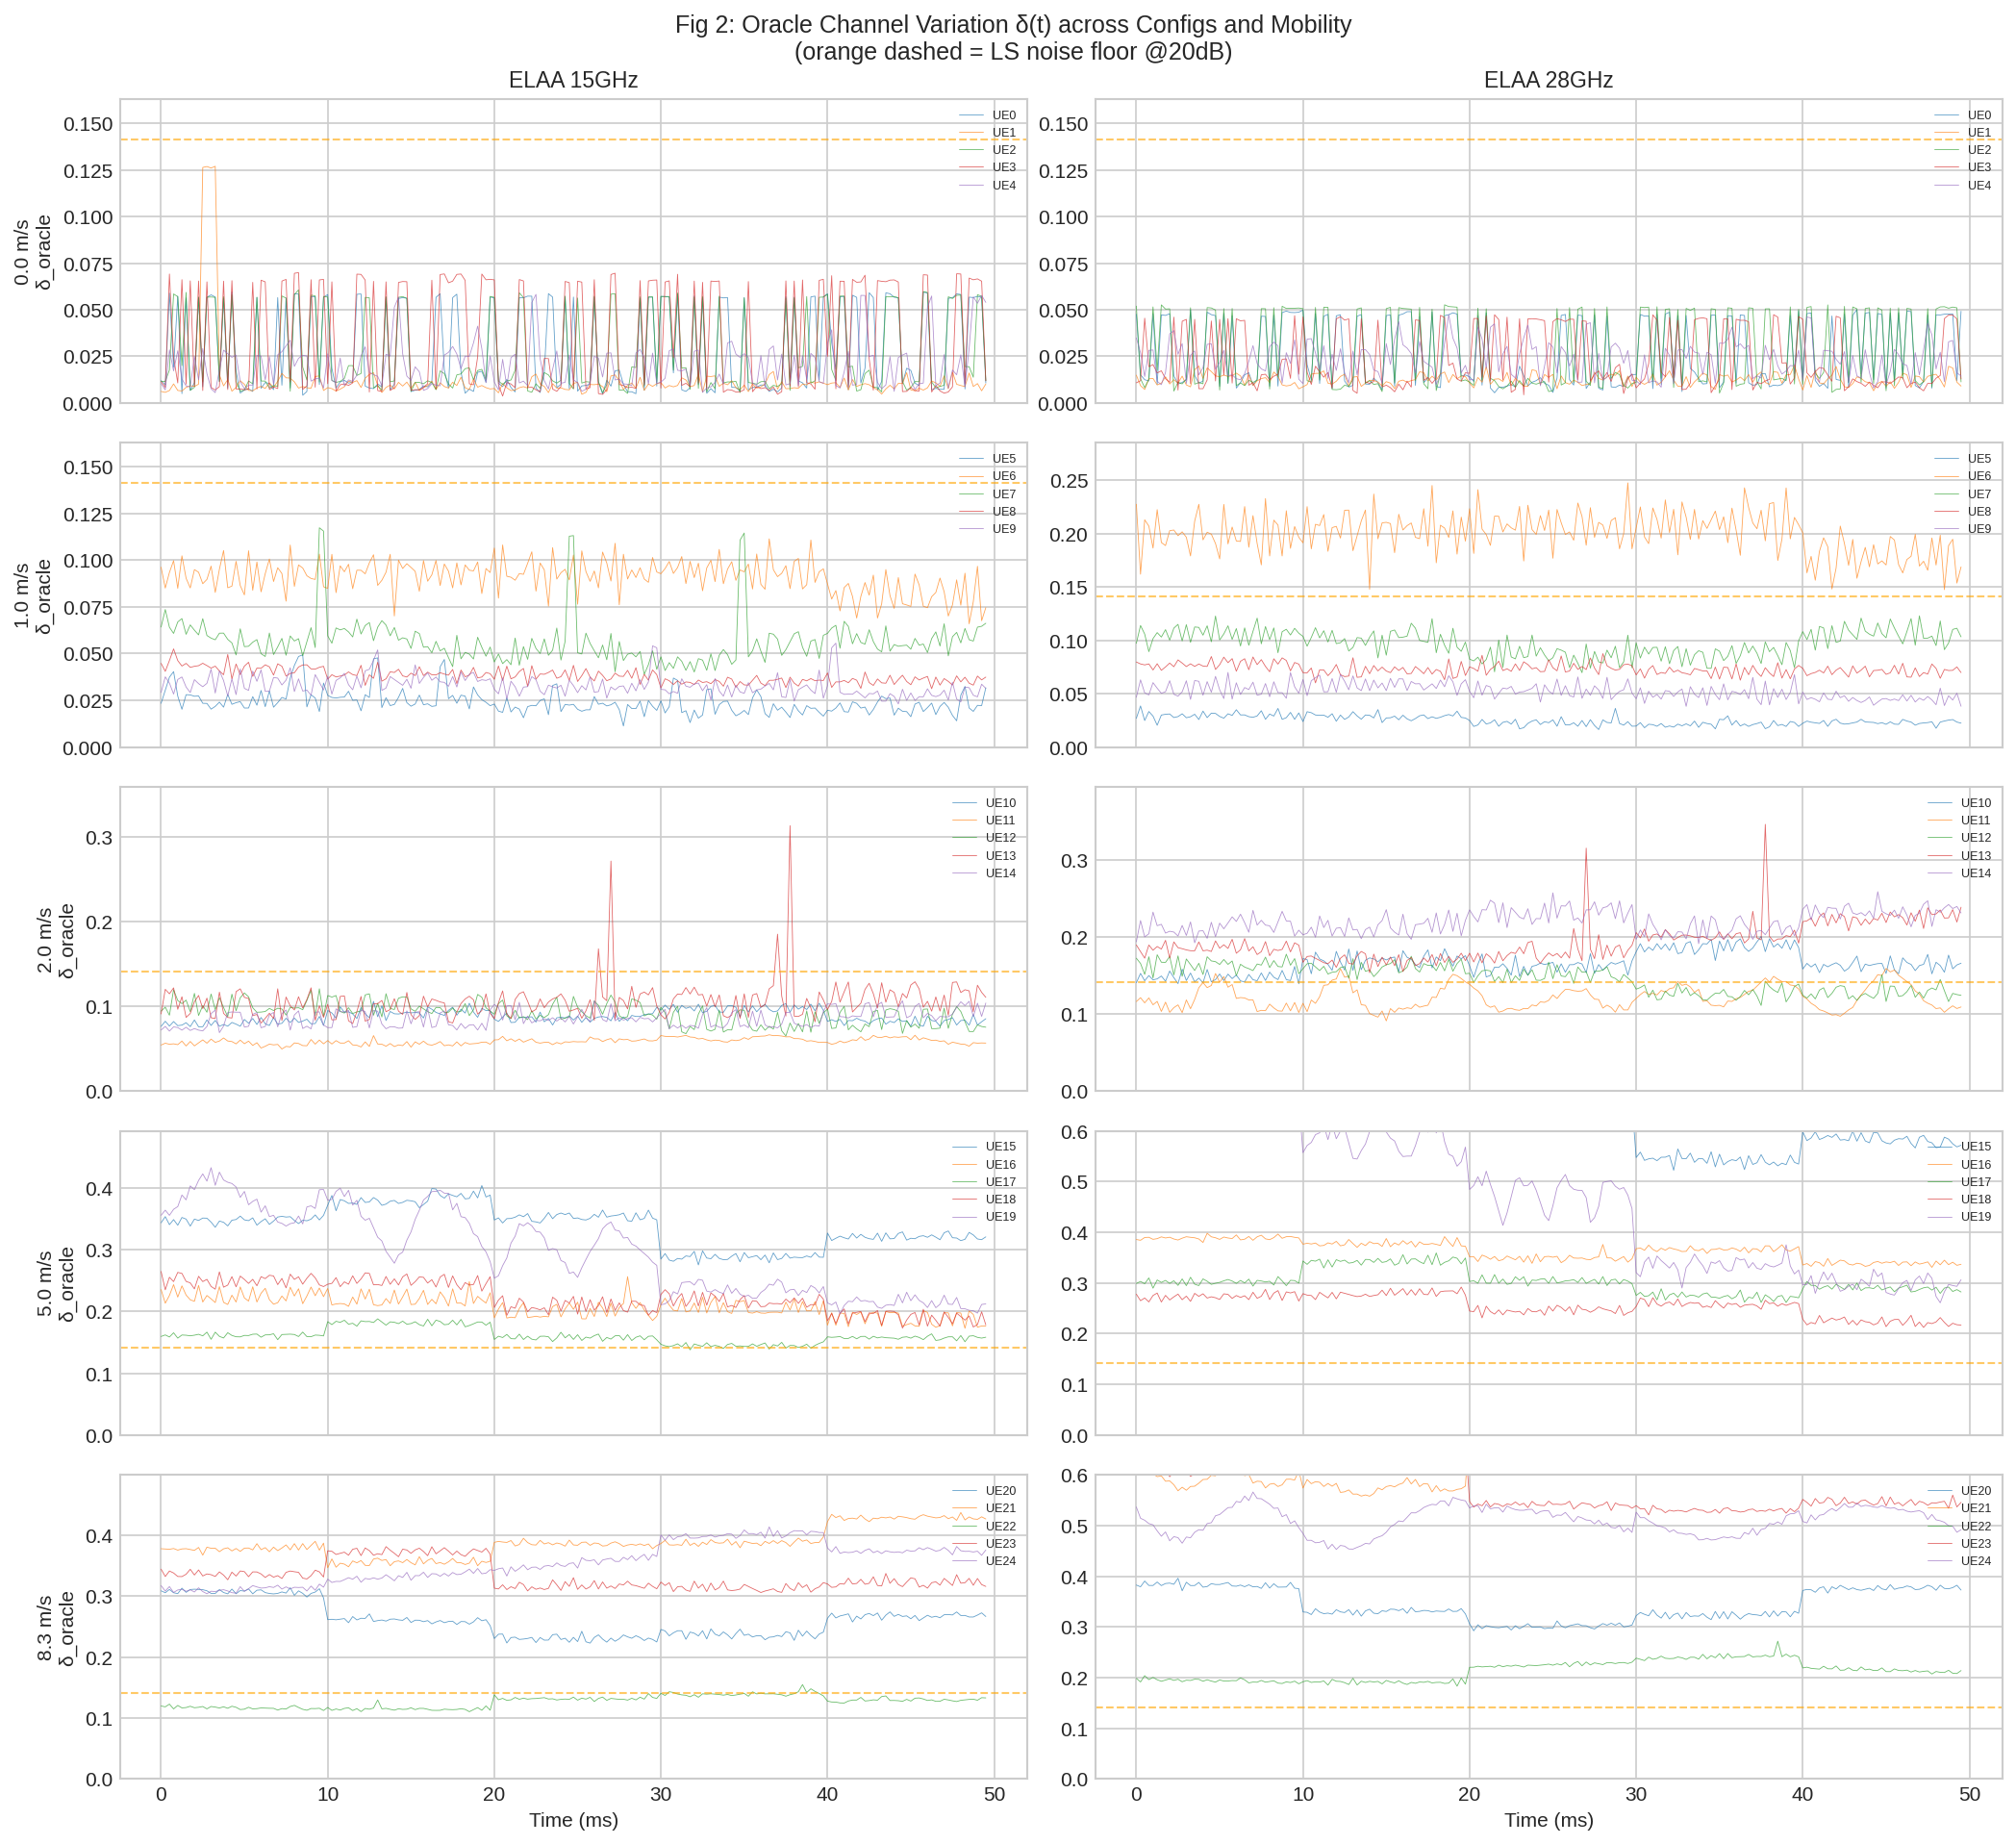

In [2]:
# Fig 2: Oracle δ time series — N speeds × N configs
n_speeds = len(SPEED_ORDER)
fig, axes = plt.subplots(n_speeds, len(PRESETS), figsize=(14, 2.6 * n_speeds), sharex=True)
if len(PRESETS) == 1:
    axes = axes[:, np.newaxis]
# dt_ms per preset (from config numerology_mu → slot_duration_s)
dt_ms_map = {p: all_ue_data[p]["cfg"].slot_duration_s * 1000 for p in PRESETS if p in all_ue_data}

for col, preset in enumerate(PRESETS):
    ud = all_ue_data.get(preset)
    if ud is None:
        for row in range(n_speeds):
            axes[row, col].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[row, col].transAxes)
        continue
    
    groups = group_by_speed(ud["ue_list"])
    
    for row, spd_lbl in enumerate(SPEED_ORDER):
        ax = axes[row, col]
        for u in groups.get(spd_lbl, []):
            # Use cached d_oracle instead of manual computation (#2)
            delta = u["d_oracle"]
            t_ms = np.arange(len(delta)) * dt_ms_map[preset]
            ax.plot(t_ms, delta, lw=0.4, alpha=0.7, label=f"UE{u['uid']}")
        
        ax.axhline(NOISE_FLOOR, color="orange", ls="--", lw=1, alpha=0.6)
        # Coherence time reference line
        if preset in COHERENCE and spd_lbl in COHERENCE[preset]:
            T_c_slots = COHERENCE[preset][spd_lbl]
            if T_c_slots < 1e6:
                T_c_ms = T_c_slots * dt_ms_map[preset]
                ax.axvline(T_c_ms, color="red", ls=":", lw=1, alpha=0.5)
                ax.text(T_c_ms, ax.get_ylim()[1]*0.95, f"T_c={T_c_ms:.1f}ms",
                        fontsize=6, color="red", ha="left", va="top")
        ax.set_ylim(0, min(0.6, ax.get_ylim()[1] * 1.1) if groups.get(spd_lbl) else 0.6)
        if row == 0:
            ax.set_title(PRESET_LABELS[preset], fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{spd_lbl} m/s\nδ_oracle")
        if row == n_speeds - 1:
            ax.set_xlabel("Time (ms)")
        ax.legend(fontsize=6, loc="upper right")

fig.suptitle("Fig 2: Oracle Channel Variation δ(t) across Configs and Mobility\n"
             "(orange dashed = LS noise floor @20dB)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig2_delta_timeseries.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

## Fig 3: NMSE vs Threshold — noise floor is safe skip level

### LS Monitor Noise Floor Derivation

In OFDM systems, the LS channel estimate at subcarrier $k$ is:

$$\hat{H}_{\text{LS}}[k] = \frac{Y[k]}{X[k]} = H[k] + \frac{N[k]}{X[k]}$$

where $Y[k]$ is the received DMRS, $X[k]$ is the known pilot, $N[k] \sim \mathcal{CN}(0, \sigma^2_n)$ is AWGN.

The **Channel Estimation Error Variance** of the LS estimator is:

$$\sigma^2_{\text{CE}} = \mathbb{E}\left[|\hat{H}_{\text{LS}} - H|^2\right] = \frac{\sigma^2_n}{|X|^2} = \frac{\sigma^2_n}{E_p} = \frac{1}{\text{SNR}}$$

where $E_p = |X|^2$ is the pilot energy. At SNR = 20 dB: $\sigma^2_{\text{CE}} = 0.01$.

Now, the scheduling monitor computes the **normalized LS difference**:

$$\delta_{\text{LS}}(t) = \frac{\|\hat{\mathbf{h}}_{\text{LS}}(t) - \hat{\mathbf{h}}_{\text{LS}}(t-1)\|}{\|\hat{\mathbf{h}}_{\text{LS}}(t-1)\|}$$

For a **static channel** ($\mathbf{h}(t) = \mathbf{h}(t-1)$), the numerator reduces to the difference of two independent noise vectors:

$$\hat{\mathbf{h}}_{\text{LS}}(t) - \hat{\mathbf{h}}_{\text{LS}}(t-1) = \mathbf{n}(t) - \mathbf{n}(t-1)$$

where $\mathbf{n}(t), \mathbf{n}(t-1) \sim \mathcal{CN}(\mathbf{0}, \sigma^2_{\text{CE}} \mathbf{I})$ are i.i.d. The squared norm:

$$\mathbb{E}\left[\|\mathbf{n}(t) - \mathbf{n}(t-1)\|^2\right] = 2 \sigma^2_{\text{CE}} \cdot D = \frac{2D}{\text{SNR}}$$

where $D = N_{\text{ant}} \times N_{\text{sc}}$ is the total channel dimension. Meanwhile:

$$\mathbb{E}\left[\|\hat{\mathbf{h}}_{\text{LS}}\|^2\right] \approx \|\mathbf{h}\|^2 + \sigma^2_{\text{CE}} \cdot D \approx \|\mathbf{h}\|^2 \quad (\text{high SNR})$$

Therefore the **noise floor** of $\delta_{\text{LS}}$ is:

$$\boxed{\delta_{\text{floor}} = \sqrt{\frac{2}{\text{SNR}_{\text{linear}}}} \approx 0.141 \quad \text{at 20 dB}}$$

**Physical interpretation**: Even when the channel is perfectly static, the LS monitor reports $\delta \approx 0.14$ due to estimation noise. Any true channel variation with $\delta_{\text{oracle}} < \delta_{\text{floor}}$ is **masked by noise** and cannot be detected by the LS monitor.

**Implication for scheduling**: Setting $\tau = \delta_{\text{floor}}$ means the scheduler skips CE whenever the *observed* variation is below the noise floor. For static/slow UEs where $\delta_{\text{oracle}} \ll \delta_{\text{floor}}$, this is safe — the "variation" is entirely noise.

In [ ]:
# Fig 3: NMSE vs τ — noise floor skip test across all configs
thresholds = np.linspace(0.001, 0.3, 25).tolist()

fig, axes = plt.subplots(1, len(PRESETS), figsize=(15, 4.5))

for col, preset in enumerate(PRESETS):
    ax = axes[col]
    ud = all_ue_data.get(preset)
    if ud is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue
    
    seen_labels = set()  # N7: O(1) label dedup
    for u in tqdm(ud["ue_list"], desc=f"Fig3 {PRESET_LABELS[preset]}", leave=False):
        h, h_ls, d_oracle = u["h_real"], u["h_ls"], u["d_oracle"]  # #2: cached
        lbl = u["spd"]
        color = SPEED_COLORS[lbl]
        
        # Oracle scheduling sweep — N3: parallel via _batch_nmse_multi_tau
        results = u["tau_sweep_oracle"]  # precomputed in Cell 1
        nmses_o = [10 * np.log10(max(np.mean(r["nmse_arr"]), 1e-30)) for r in results]
        
        show_label = f"{lbl} m/s" if lbl not in seen_labels else ""
        if show_label: seen_labels.add(lbl)
        ax.plot(thresholds, nmses_o, "-", color=color, lw=1.2, alpha=0.7, label=show_label)
    
    ax.axvline(NOISE_FLOOR, color="orange", ls=":", lw=2, label=f"NF={NOISE_FLOOR:.3f}")
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
    ax.set_xlabel("Threshold τ"); ax.set_ylabel("NMSE (dB)")
    ax.set_title(PRESET_LABELS[preset])
    ax.legend(fontsize=7)
    ax.set_ylim(-25, 0)

fig.suptitle("Fig 3: NMSE vs Skip Threshold (Oracle δ scheduling, EMA α=0.7)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig3_nmse_vs_tau.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

Fig3 ELAA 15GHz:   0%|          | 0/25 [00:00<?, ?it/s]

## Fig 3b: α Scheduling Strategy Comparison
**Message**: Proportional blending (α=δ/τ) outperforms binary skip/full across all UE types.
- Full CE baseline at -20dB
- Binary fails catastrophically on multipath pedestrian (UE4)
- δ/τ provides 9dB improvement on static UEs via temporal noise averaging
- Oracle sigmoid fit shows theoretical upper bound (sharp transition)
- **c=1.0 (τ=NF) is the universal safe operating point**

Data pre-computed in `assets/results/paper_cache/alpha_strategies.json`.
Plot script: `scripts/plot_alpha_strategies.py`.

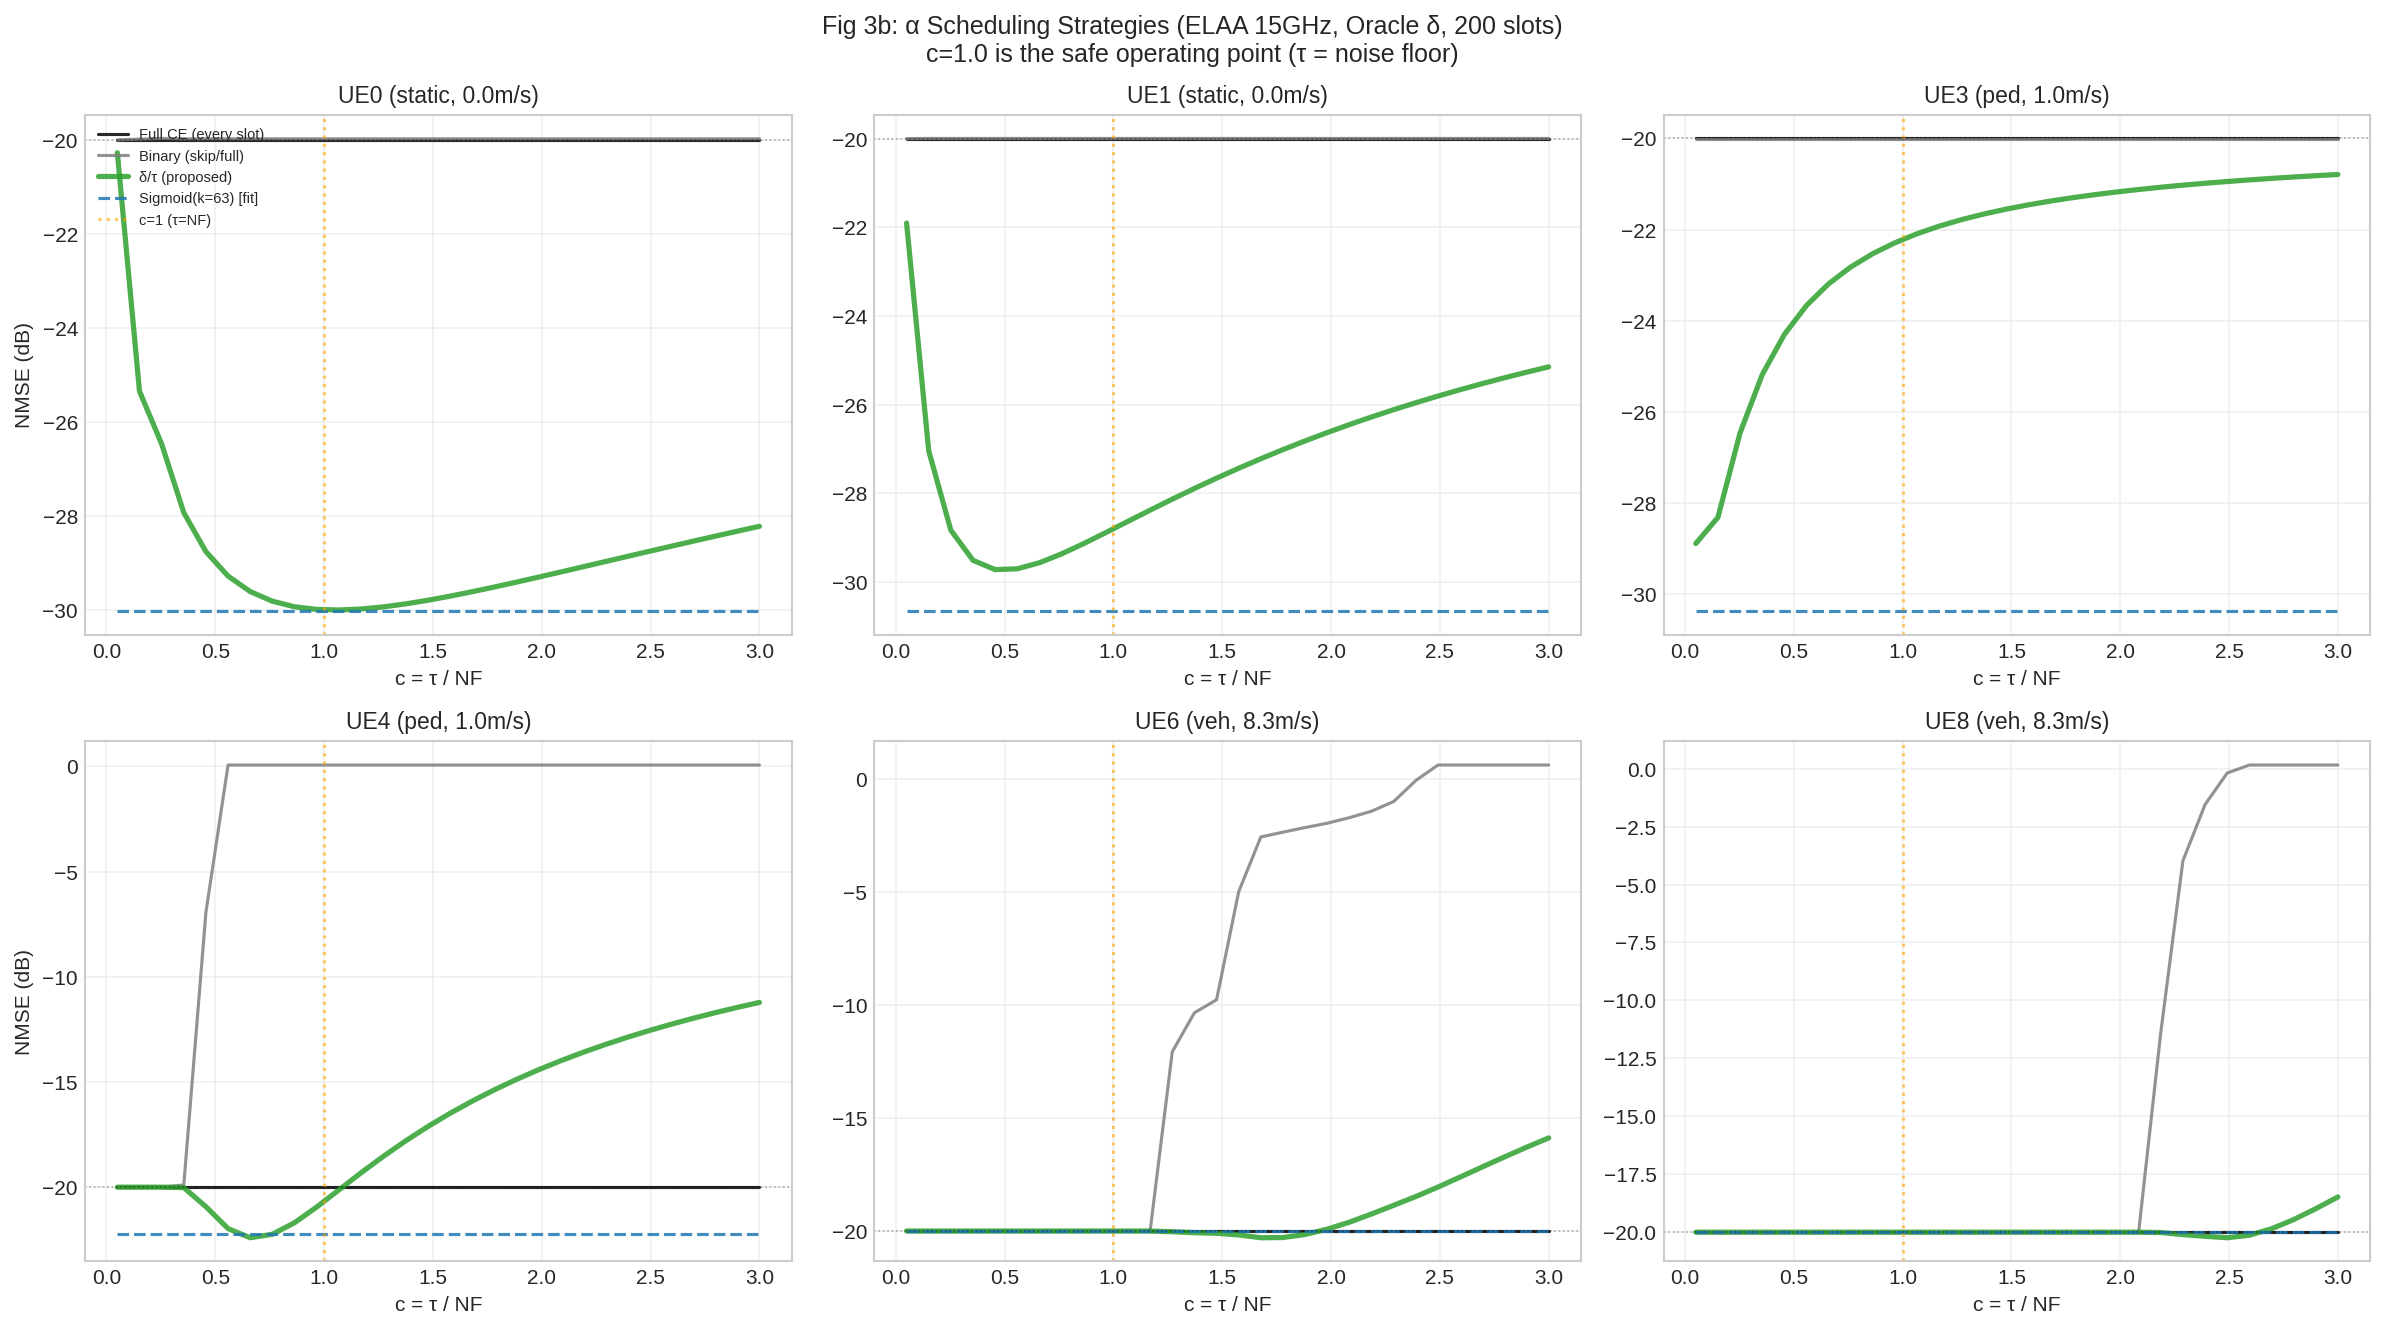


Strategy                       UE 0 UE 1 UE 3 UE 4 UE 6 UE 8
Full CE (every slot)           -20.0 -20.0 -20.0 -20.0 -20.0 -20.0
Binary (skip/full)             -20.0 -20.0 -20.0   0.1 -20.0 -20.0
δ/τ (proposed)                 -30.0 -28.9 -22.3 -20.9 -20.0 -20.0
Sigmoid(k=63) [fit]            -30.0 -30.7 -30.4 -22.2 -20.0 -20.0


In [ ]:
# ═══ Fig 3b: α Strategy Comparison (from cached data) ═══
import json as _json

CACHE = "../../assets/results/paper_cache/alpha_strategies.json"
with open(CACHE) as f:
    strat_data = _json.load(f)

c_vals = strat_data["c_values"]
NF_val = strat_data["noise_floor"]

# 4 representative strategies
show_strats = [
    ("Full CE (every slot)",  "black",    "-",  1.5),
    ("Binary (skip/full)",    "tab:gray", "-",  1.5),
    ("δ/τ (proposed)",        "tab:green","-",  2.5),
    ("Sigmoid(k=63) [fit]",   "tab:blue", "--", 1.5),
]

ue_order = sorted(strat_data["ues"].keys(), key=int)
n_ues = len(ue_order)
n_cols = 5
n_rows = (n_ues + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for idx, uid in enumerate(ue_order):
    ax = axes[idx]
    ue = strat_data["ues"][uid]
    
    for sname, color, ls, lw in show_strats:
        if sname in ue["nmse"]:
            ax.plot(c_vals, ue["nmse"][sname], ls, color=color, lw=lw, alpha=0.85, label=sname)
    
    ax.axvline(1.0, color="orange", ls=":", lw=1.5, alpha=0.6, label="c=1 (τ=NF)")
    ax.axhline(-20.0, color="black", ls=":", lw=0.8, alpha=0.3)
    ax.set_title(f"UE{uid} ({ue['cat']}, {ue['speed']:.1f}m/s)", fontsize=11)
    ax.set_xlabel("c = τ / NF")
    if idx % n_cols == 0:
        ax.set_ylabel("NMSE (dB)")
    if idx == 0:
        ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("Fig 3b: α Scheduling Strategies (ELAA 15GHz, Oracle δ, 200 slots)\n"
             "c=1.0 is the safe operating point (τ = noise floor)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig3b_alpha_strategies.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# Summary table at c=1.0
c1_idx = min(range(len(c_vals)), key=lambda i: abs(c_vals[i] - 1.0))
print(f"\n{'Strategy':<30}", end="")
for uid in ue_order:
    print(f" UE{uid:>2}", end="")
print()
for sname, _, _, _ in show_strats:
    print(f"{sname:<30}", end="")
    for uid in ue_order:
        ue = strat_data["ues"][uid]
        if sname in ue["nmse"]:
            print(f" {ue['nmse'][sname][c1_idx]:>5.1f}", end="")
        else:
            print(f"   N/A", end="")
    print()

## Fig 4: Feature Comparison — Which Monitor Feature is Best?

**질문**: scheduling monitor가 δ를 계산할 때, 어떤 feature를 써야 하나?

4가지 후보 feature를 동일한 threshold sweep으로 비교.
각 feature에 대해 τ를 5th~99th percentile로 sweep → (skip rate, NMSE) 쌍을 얻음.

**X축 = Skip Rate (SR)**: threshold τ를 올릴수록 더 많은 slot을 skip → SR 증가.
동일 SR에서 NMSE가 낮은 feature가 "같은 연산 절감으로 더 좋은 품질"을 달성.

**비교 대상:**
- **LS δ** (red): `||h_LS(t) - h_LS(t-1)|| / ||h_LS(t-1)||` — 관측 가능, practical
- **Oracle δ** (blue): ground truth h로 계산 — 이론적 upper bound
- **Power δ** (purple): `|P(t) - P(t-1)| / P(t-1)` — 수신 전력 변화
- **Decorrelation** (orange): `1 - Re⟨h(t), h(t-1)⟩ / (||h(t)|| · ||h(t-1)||)` — 상관도 변화

**기대 결과**: Oracle δ가 best (cheating), LS δ가 practical best.
Power/Decorrelation은 subcarrier-level 정보를 잃어서 성능 열세.

**해석**: Pareto front에서 왼쪽 아래(높은 SR, 낮은 NMSE)에 가까울수록 좋은 feature.

Fig4 ELAA 15GHz:   0%|          | 0/25 [00:00<?, ?it/s]

Fig4 ELAA 28GHz:   0%|          | 0/25 [00:00<?, ?it/s]

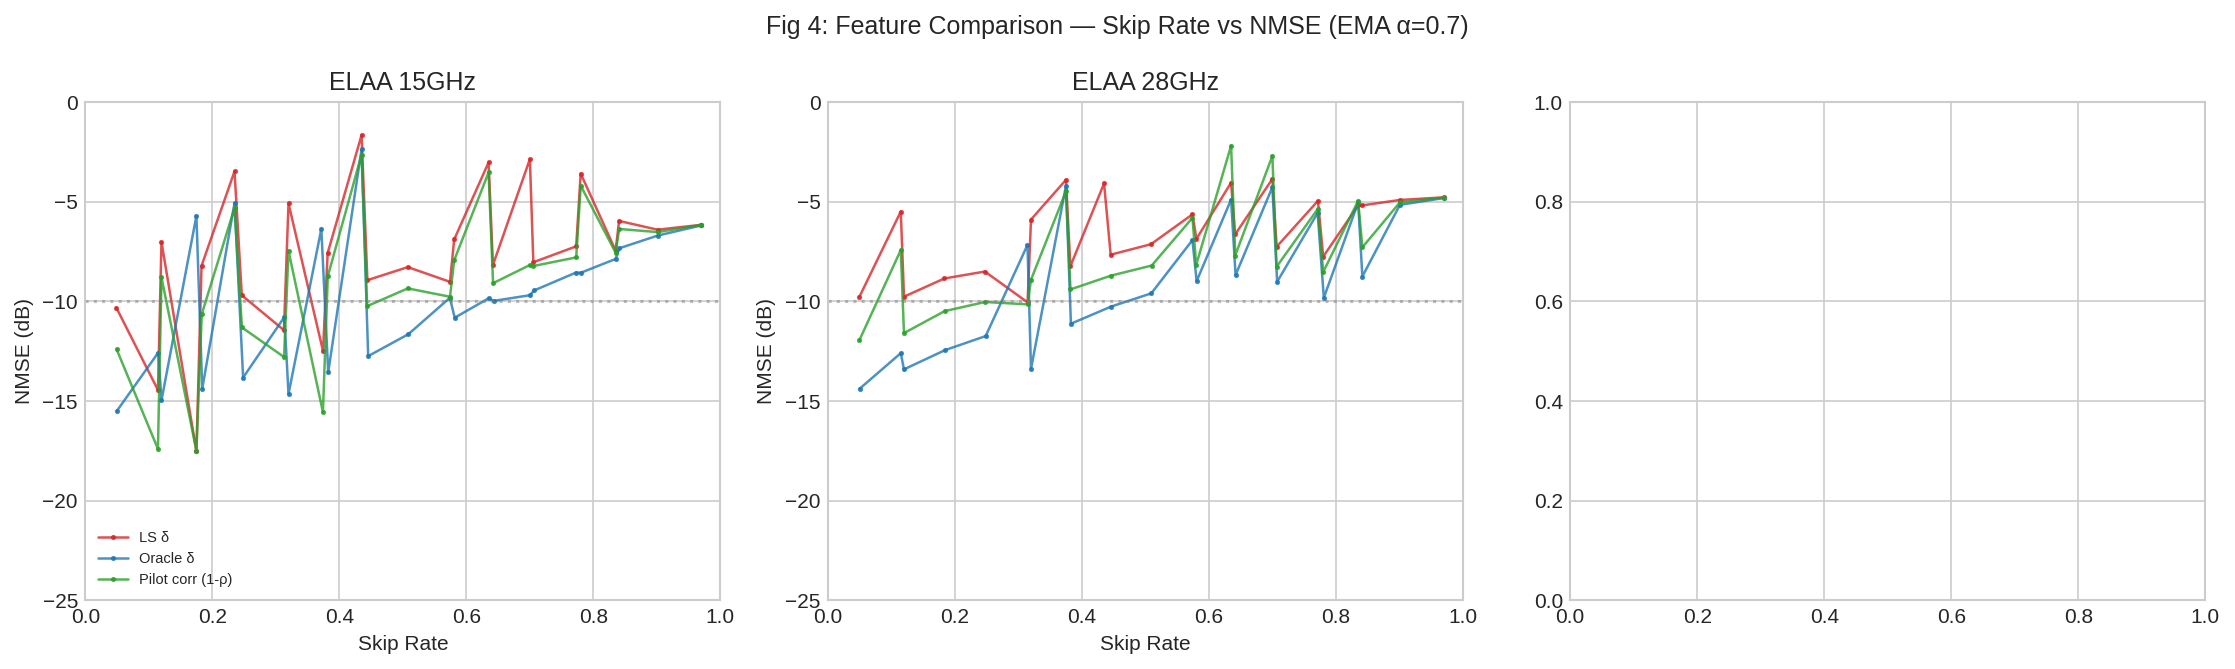

In [ ]:
# Fig 4: Feature comparison Pareto front — all configs
def compute_features_from_cache(h_ls, h_real):
    """Compute features from cached h_ls (no new noise). N1: cache norms."""
    h_flat = h_ls.flatten(1)
    h_flat_o = h_real.flatten(1)
    # N1: pre-compute norms once
    norm_prev = h_flat[:-1].norm(dim=1)
    norm_next = h_flat[1:].norm(dim=1)
    
    features = {}
    diff = h_flat[1:] - h_flat[:-1]
    features["LS δ"] = (diff.norm(dim=1) / norm_prev.clamp(min=1e-12)).numpy()
    diff_o = h_flat_o[1:] - h_flat_o[:-1]
    features["Oracle δ"] = (diff_o.norm(dim=1) / h_flat_o[:-1].norm(dim=1).clamp(min=1e-12)).numpy()
    power = h_flat.pow(2).sum(1)
    features["Power δ"] = (torch.abs(power[1:] - power[:-1]) / power[:-1].clamp(min=1e-12)).numpy()
    dot = (h_flat[1:] * h_flat[:-1]).sum(1)
    norms = norm_next * norm_prev  # N1: reuse cached norms
    features["Decorrelation"] = (1 - dot / norms.clamp(min=1e-12)).numpy()

    # ── New cheap features ──
    # Pilot correlation (1-ρ): raw Y temporal coherence, computable BEFORE LS
    # In practice: Re⟨Y(t), Y(t-1)⟩ / ||Y||². Here we use h_ls as proxy for Y.
    dot_real = torch.real(torch.sum(h_flat[1:].conj() * h_flat[:-1], dim=1)) if h_flat.is_complex() \
        else (h_flat[1:] * h_flat[:-1]).sum(1)
    features["Pilot corr (1-ρ)"] = (1 - dot_real / norms.clamp(min=1e-12)).numpy()

    # Max subcarrier δ: worst-case per-SC change (catches localized freq-domain shifts)
    N_sc = h_ls.shape[-1] if h_ls.dim() >= 2 else 1
    if N_sc > 1:
        h_sc = h_ls if h_ls.dim() == 2 else h_ls.flatten(1)
        sc_diff = (h_sc[1:] - h_sc[:-1]).abs()
        features["Max SC δ"] = (sc_diff.max(dim=1).values / norm_prev.clamp(min=1e-12)).numpy()

    # Doppler from pilots: mean phase rotation between consecutive slots
    if h_flat.is_complex():
        phase_rot = torch.angle(h_flat[1:] * h_flat[:-1].conj())
        features["Doppler (|φ̄|)"] = torch.abs(phase_rot.mean(dim=1)).numpy()
    else:
        # Real-valued: approximate via atan2 of cross/dot terms
        # Skip — Doppler only meaningful for complex channels
        pass

    # Coherence BW δ: correlation between adjacent subcarriers, change over time
    if N_sc > 1 and h_ls.dim() >= 2:
        h_sc = h_ls if h_ls.dim() == 2 else h_ls.flatten(1)
        # corr(H_k, H_{k+1}) per slot
        def _coh_bw(h):
            a, b = h[:, :-1], h[:, 1:]
            if h.is_complex():
                dot_ab = torch.real(torch.sum(a.conj() * b, dim=1))
            else:
                dot_ab = (a * b).sum(1)
            na = a.norm(dim=1).clamp(min=1e-12)
            nb_ = b.norm(dim=1).clamp(min=1e-12)
            return dot_ab / (na * nb_)
        coh = _coh_bw(h_sc)
        features["Coh BW δ"] = torch.abs(coh[1:] - coh[:-1]).numpy()

    return features

percentiles = np.linspace(5, 99, 15)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
feat_colors = {
    "LS δ": "tab:red", "Oracle δ": "tab:blue", "Power δ": "tab:purple",
    "Decorrelation": "tab:orange", "Pilot corr (1-ρ)": "tab:green",
    "Max SC δ": "tab:brown", "Doppler (|φ̄|)": "tab:cyan", "Coh BW δ": "tab:pink",
}
# Only plot the interesting ones (skip Power δ and Decorrelation, superseded)
feat_plot = ["LS δ", "Oracle δ", "Pilot corr (1-ρ)", "Doppler (|φ̄|)"]

for col, preset in enumerate(PRESETS):
    ax = axes[col]
    ud = all_ue_data.get(preset)
    if ud is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue
    
    feat_results = {}
    for u in tqdm(ud["ue_list"], desc=f"Fig4 {PRESET_LABELS[preset]}", leave=False):
        h, h_ls = u["h_real"], u["h_ls"]  # #3: cached h_ls
        features = compute_features_from_cache(h_ls, h)
        for fn, fv in features.items():
            if fn not in feat_plot:
                continue
            if fn not in feat_results:
                feat_results[fn] = []
            # #5: parallel tau sweep via _batch_nmse_multi_tau
            tau_list = np.percentile(fv, percentiles).tolist()
            results = _batch_nmse_multi_tau(h, h_ls, fv, tau_list, alpha_mode="ramp")
            for r in results:
                feat_results[fn].append({
                    "sr": r["n_skip"] / r["total"],
                    "nmse": 10 * np.log10(max(np.mean(r["nmse_arr"]), 1e-30))
                })
    
    # N2: proper binning instead of round(sr, 2) dict key
    for fn, pts in feat_results.items():
        sr_arr = np.array([p["sr"] for p in pts])
        nm_arr = np.array([p["nmse"] for p in pts])
        bin_edges = np.linspace(0, 1, 51)
        bin_idx = np.digitize(sr_arr, bin_edges) - 1
        srs, nms = [], []
        for b in range(len(bin_edges) - 1):
            mask = bin_idx == b
            if mask.any():
                srs.append(sr_arr[mask].mean())
                nms.append(nm_arr[mask].mean())
        if srs:
            ax.plot(srs, nms, ".-", ms=3, lw=1.2,
                    color=feat_colors.get(fn, "gray"), label=fn, alpha=0.8)
    
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
    ax.set_title(PRESET_LABELS[preset])
    ax.set_xlim(0, 1); ax.set_ylim(-25, 0)
    if col == 0: ax.legend(fontsize=7)

fig.suptitle("Fig 4: Feature Comparison — Skip Rate vs NMSE (EMA α=0.7)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig4_feature_pareto.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

## Fig 4b: Feature–Oracle Correlation (direct)
**질문**: 어떤 observable feature가 oracle δ를 가장 잘 예측하나?

Fig 4의 Pareto는 surrogate (SR vs NMSE). 여기서는 직접적으로
**scatter(feature, oracle δ) + Pearson/Spearman ρ** 를 비교.

Data: `assets/results/paper_cache/feature_correlation.json`

Features in cache: ['LS δ', 'Pilot corr (1-ρ)', 'Max SC δ', 'Doppler (|φ̄|)', 'Coh BW δ']


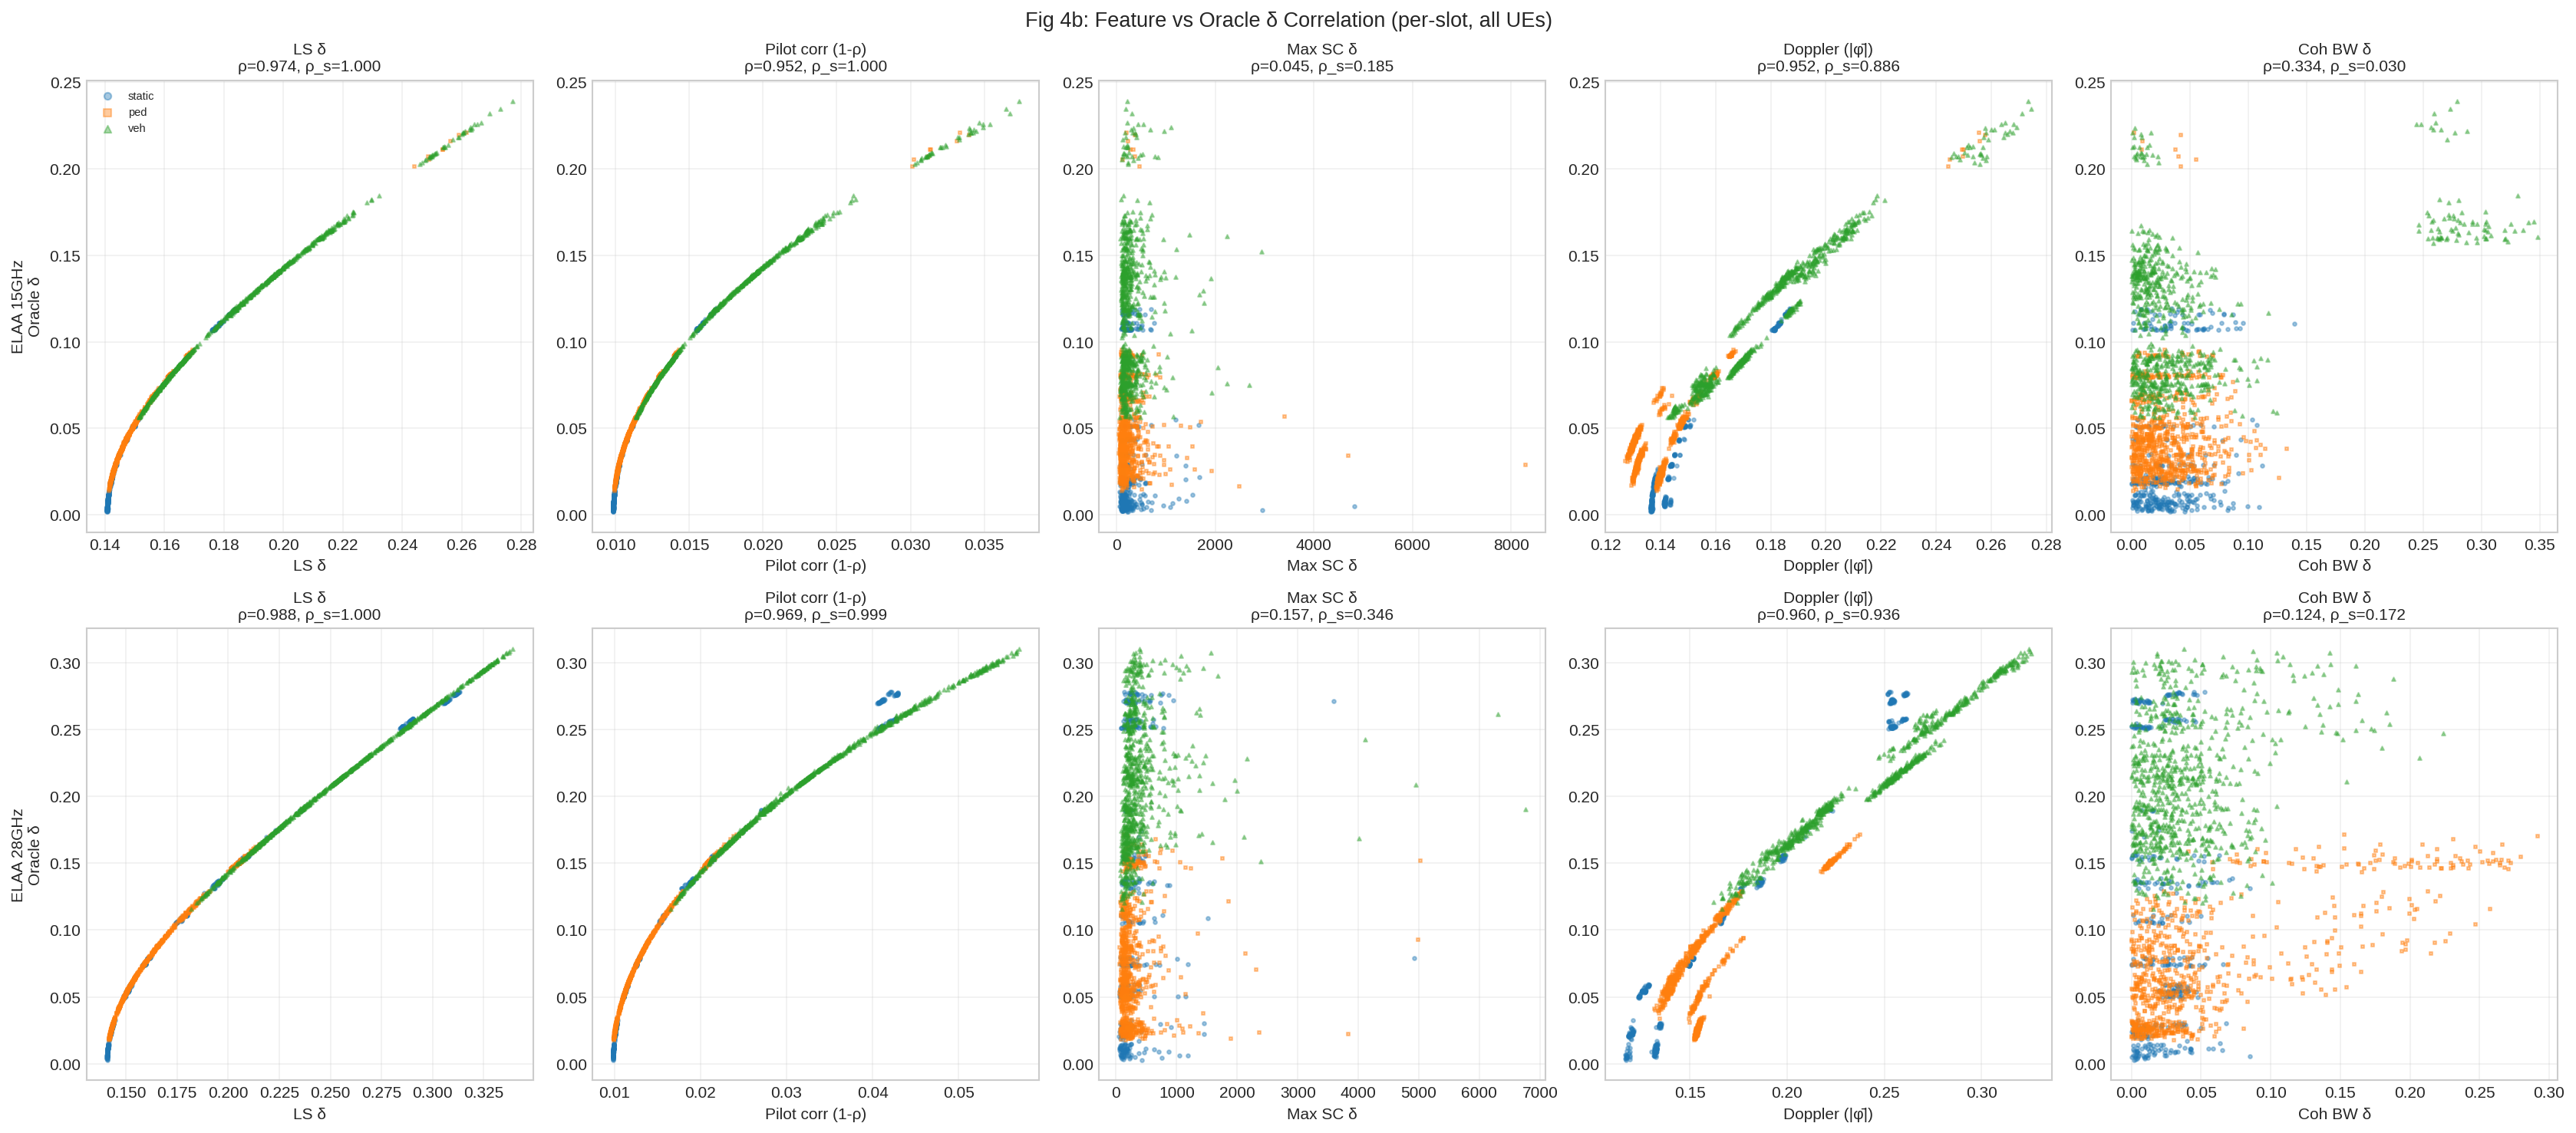


Feature                   ELAA 15GHz (ρ)    (ρ_s)      ELAA 28GHz (ρ)    (ρ_s)
------------------------------------------------------------------------------------------
LS δ                       0.9741   0.9999       0.9883   0.9999
Pilot corr (1-ρ)           0.9519   0.9998       0.9685   0.9993
Max SC δ                   0.0448   0.1845       0.1572   0.3463
Doppler (|φ̄|)             0.9523   0.8860       0.9603   0.9355
Coh BW δ                   0.3341   0.0304       0.1237   0.1717

=== Key Insight ===
ELAA 15GHz: LS δ ρ_s=0.9999, Pilot corr ρ_s=0.9998  → gap=0.0000 (Pilot corr needs NO LS!)
ELAA 28GHz: LS δ ρ_s=0.9999, Pilot corr ρ_s=0.9993  → gap=0.0006 (Pilot corr needs NO LS!)


In [ ]:
# ═══ Fig 4b: Feature vs Oracle δ Correlation ═══
import json as _json
from scipy.stats import pearsonr, spearmanr

CORR_CACHE = "../../assets/results/paper_cache/feature_correlation.json"
with open(CORR_CACHE) as f:
    corr_data = _json.load(f)

# Auto-detect features from cache (excluding Oracle δ)
_sample_preset = next(iter(corr_data))
feat_list = [f for f in corr_data[_sample_preset]["features"] if "Oracle" not in f]
print(f"Features in cache: {feat_list}")

feat_colors = {
    "LS δ": "tab:red", "Power δ": "tab:purple", "Decorrelation": "tab:orange",
    "Phase δ": "tab:cyan", "Pilot corr (1-ρ)": "tab:green",
    "Max SC δ": "tab:brown", "Doppler (|φ̄|)": "tab:cyan", "Coh BW δ": "tab:pink",
}
cat_markers = {"0": "o", "1": "s", "8.3": "^"}

n_feat = len(feat_list)
fig, axes = plt.subplots(len(PRESETS), n_feat, figsize=(4.5*n_feat, 5*len(PRESETS)))
if len(PRESETS) == 1:
    axes = axes[np.newaxis, :]

for row, preset in enumerate(PRESETS):
    if preset not in corr_data:
        continue
    r = corr_data[preset]
    oracle = np.array(r["oracle"])
    cats = np.array(r["cats"])
    
    for col, fn in enumerate(feat_list):
        ax = axes[row, col]
        fv = np.array(r["features"][fn])
        
        for cat, marker in cat_markers.items():
            mask = cats == cat
            if mask.any():
                ax.scatter(fv[mask], oracle[mask], s=5, alpha=0.4, marker=marker, label=cat)
        
        rp = r["corr"][fn]["pearson"]
        rs = r["corr"][fn]["spearman"]
        ax.set_title(f"{fn}\nρ={rp:.3f}, ρ_s={rs:.3f}", fontsize=10)
        ax.set_xlabel(fn)
        if col == 0:
            ax.set_ylabel(f"{PRESET_LABELS[preset]}\nOracle δ")
        ax.grid(True, alpha=0.3)
        if col == 0 and row == 0:
            ax.legend(fontsize=7, markerscale=2)

fig.suptitle("Fig 4b: Feature vs Oracle δ Correlation (per-slot, all UEs)", fontsize=13)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig4_correlation.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# Summary table
print(f"\n{'Feature':<20}", end="")
for preset in PRESETS:
    if preset in corr_data:
        print(f"  {PRESET_LABELS[preset]:>14} (ρ)    (ρ_s)", end="")
print()
print("-" * (20 + 35 * len(PRESETS)))
for fn in feat_list:
    print(f"{fn:<20}", end="")
    for preset in PRESETS:
        if preset in corr_data and fn in corr_data[preset]["corr"]:
            c = corr_data[preset]["corr"][fn]
            print(f"      {c['pearson']:>7.4f}  {c['spearman']:>7.4f}", end="")
        else:
            print(f"      {'N/A':>7}  {'N/A':>7}", end="")
    print()

# Highlight: architectural advantage annotation
print("\n=== Key Insight ===")
for preset in PRESETS:
    if preset not in corr_data:
        continue
    c = corr_data[preset]["corr"]
    ls_rs = c["LS δ"]["spearman"]
    pc_rs = c.get("Pilot corr (1-ρ)", {}).get("spearman", 0)
    print(f"{PRESET_LABELS[preset]}: LS δ ρ_s={ls_rs:.4f}, Pilot corr ρ_s={pc_rs:.4f}  "
          f"→ gap={ls_rs - pc_rs:.4f} (Pilot corr needs NO LS!)")

## Fig 5: Path Diversity — why same-speed UEs have different skip feasibility
**Message**: CE skip feasibility depends on multipath richness, not speed alone. LOS-dominant UEs (few paths) are always safe to skip. Multipath-rich UEs require CE even at pedestrian speed.

Uses ELAA 15GHz data (UE3 vs UE4, both ped 1m/s).

UE3 (1 path, LOS): 61 paths, energy=1.0927e-01, median δ=0.009837
UE4 (118 paths, multipath): 37 paths, energy=5.5412e-02, median δ=0.007154


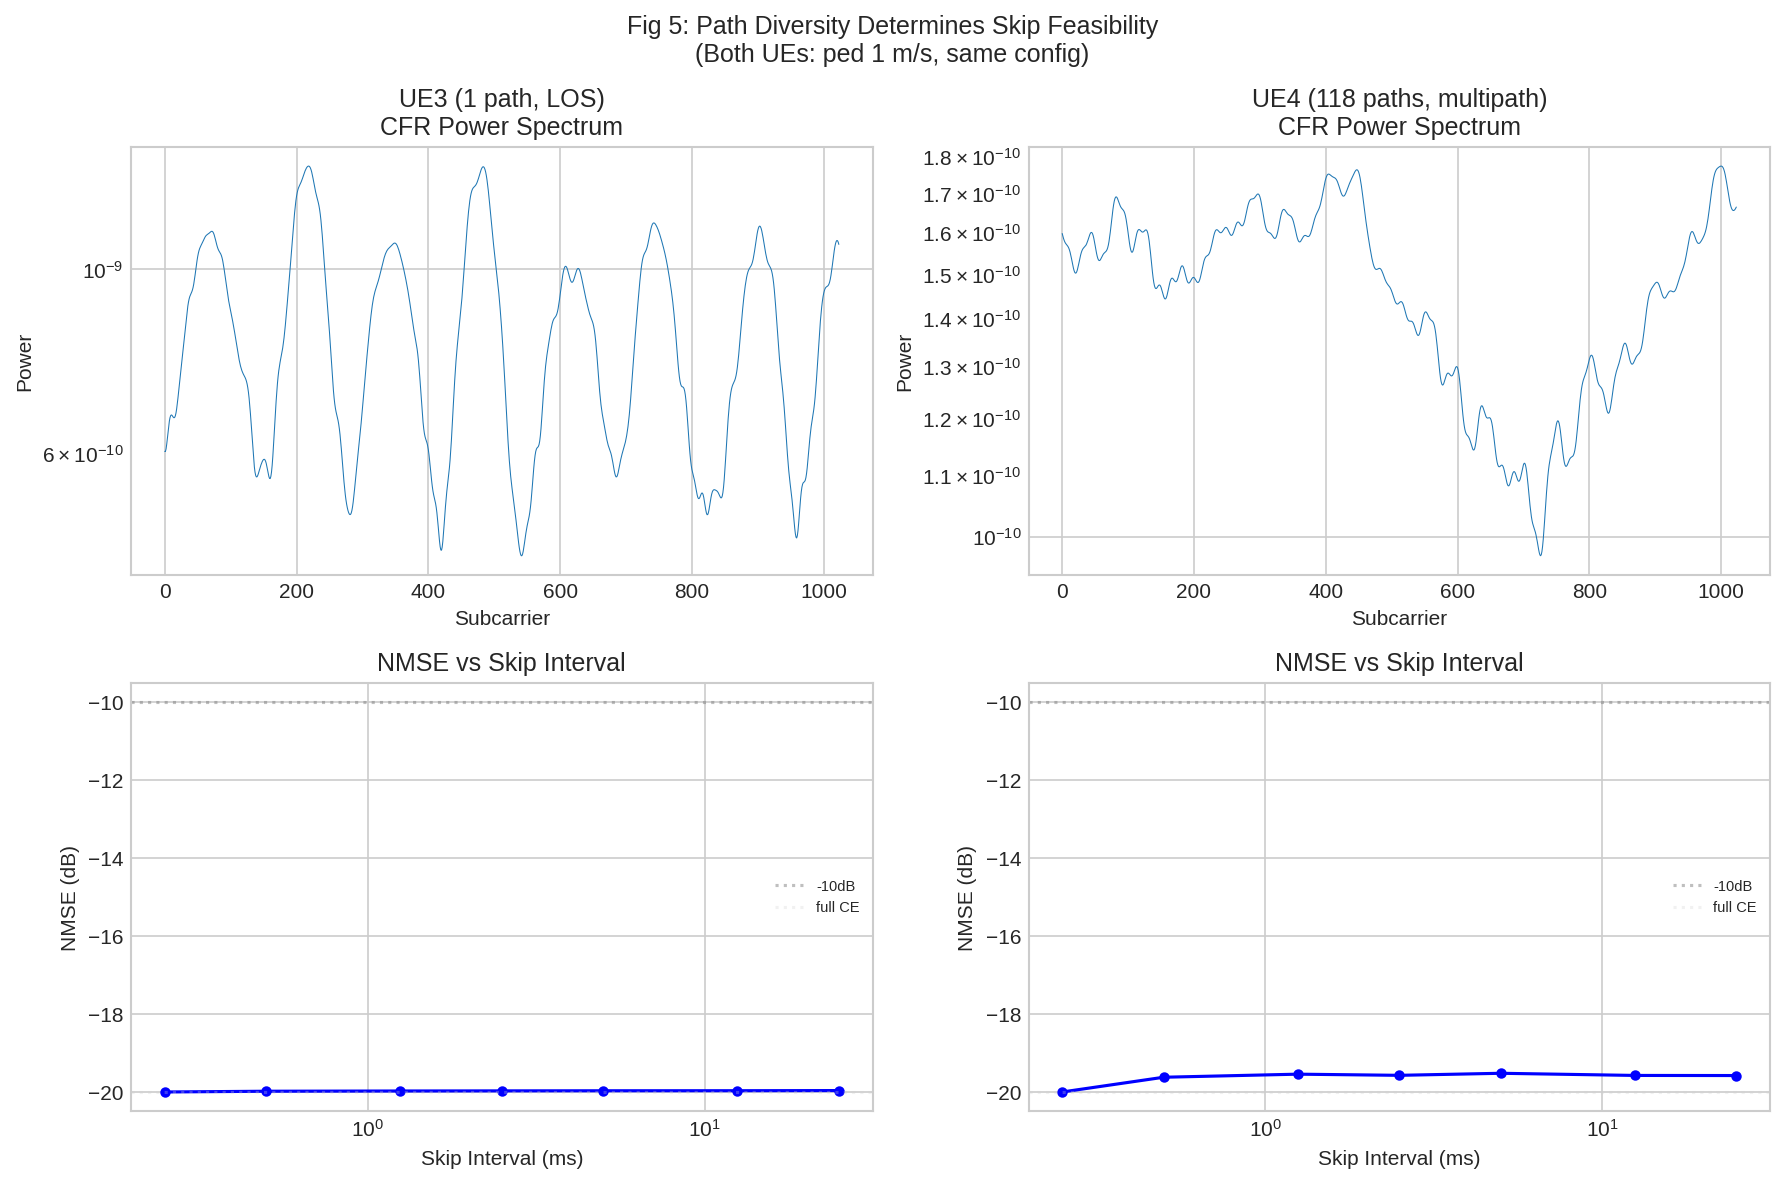

In [ ]:
# Fig 5: Path diversity — UE3 (1 path) vs UE4 (118 paths), both ped 1m/s
import h5py

ud = all_ue_data.get("munich_elaa_m_1k_15g")
if ud is not None:
    ue3 = next((u for u in ud["ue_list"] if u["uid"] == 3), None)
    ue4 = next((u for u in ud["ue_list"] if u["uid"] == 4), None)
    
    if ue3 and ue4:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        h5_path = str(ud["cfg"].temporal_dir / "channels.h5")
        
        with h5py.File(h5_path, "r") as f:  # N4: context manager
            for col, (u, uid, label) in enumerate([(ue3, 3, "UE3 (1 path, LOS)"), (ue4, 4, "UE4 (118 paths, multipath)")]):
                h = u["h_real"]
                
                # Top: CFR power spectrum
                ax = axes[0, col]
                h0 = h[0]
                avg_sc_power = h0.pow(2).sum(0).mean(0).numpy()
                ax.semilogy(avg_sc_power, lw=0.5, color="tab:blue")
                ax.set_xlabel("Subcarrier"); ax.set_ylabel("Power")
                ax.set_title(f"{label}\nCFR Power Spectrum")
                
                # Bottom: NMSE vs skip interval — use cached h_ls (#2)
                ax = axes[1, col]
                h_ls = u["h_ls"]
                d_oracle = u["d_oracle"]
                
                skip_intervals = [1, 2, 5, 10, 20, 50, 100, 200, 500]
                T = h.shape[0]
                nmses = []
                for interval in skip_intervals:
                    if interval >= T: 
                        nmses.append(float("nan"))
                        continue
                    tiers = np.zeros(T, dtype=np.int32)
                    tiers[0] = 2
                    for t in range(1, T):
                        if t % interval == 0: tiers[t] = 2
                    nm = _compute_nmse_from_tiers(h, h_ls, tiers, alpha=0.7, delta_mode="ema")
                    nmses.append(10 * np.log10(max(np.mean(nm), 1e-30)))
                
                intervals_ms = [i * 0.25 for i in skip_intervals]
                ax.plot(intervals_ms, nmses, "b-o", ms=4)
                ax.axhline(-10, color="gray", ls=":", alpha=0.5, label="-10dB")
                ax.axhline(-20, color="lightgray", ls=":", alpha=0.3, label="full CE")
                ax.set_xlabel("Skip Interval (ms)"); ax.set_ylabel("NMSE (dB)")
                ax.set_xscale("log")
                ax.set_title(f"NMSE vs Skip Interval")
                ax.legend(fontsize=7)
                
                # N4: cache cir_a data to avoid double indexing
                cir_data = np.abs(f["cir_a"][0, uid])
                n_paths = np.count_nonzero(cir_data.sum(axis=(0,1)))
                energy = cir_data.sum()
                print(f"{label}: {n_paths} paths, energy={energy:.4e}, median δ={np.median(d_oracle):.6f}")
        
        fig.suptitle("Fig 5: Path Diversity Determines Skip Feasibility\n"
                     "(Both UEs: ped 1 m/s, same config)", fontsize=12)
        plt.tight_layout()
        plt.savefig("../../assets/plots/paper_fig5_path_diversity.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)
else:
    print("ELAA 15GHz data not loaded")


## Fig 5b: Controlled Experiment — Static vs Moving at Same Position
**Message**: CE skip feasibility = f(mobility × path diversity).
- UE4 (118-path) fixed at its position: δ drops 6.4× (0.057 → 0.009)
- UE3 (1-path LOS) fixed: δ stays ~0 (already negligible)
- **Multipath richness alone doesn't prevent skipping — movement through multipath does**

Uses controlled datagen: `assets/data/channels_elaa_m_1k_15g_ue34_static/`

## Fig 6 (Table): Computation Savings — CE cost × skip rate = actual time saved
**Message**: NMSE tradeoff is CE-agnostic, but **time savings scale with CE cost**. DL-CE benefits most from skip scheduling.

**Measured CE costs (A100, ELAA 512×1584 input, batch=1):**
| CE Method | Time | Params |
|-----------|------|--------|
| LS (Y/X) | 0.01ms | 0 |
| PACENet (Small, new default) | **0.9ms** | 57K |
| PACENet (Default, old) | 6.8ms | 373K |
| ResNet-8 | 31.2ms | 595K |

Skip monitor cost: ~0.005ms (2 norms + 1 subtraction).

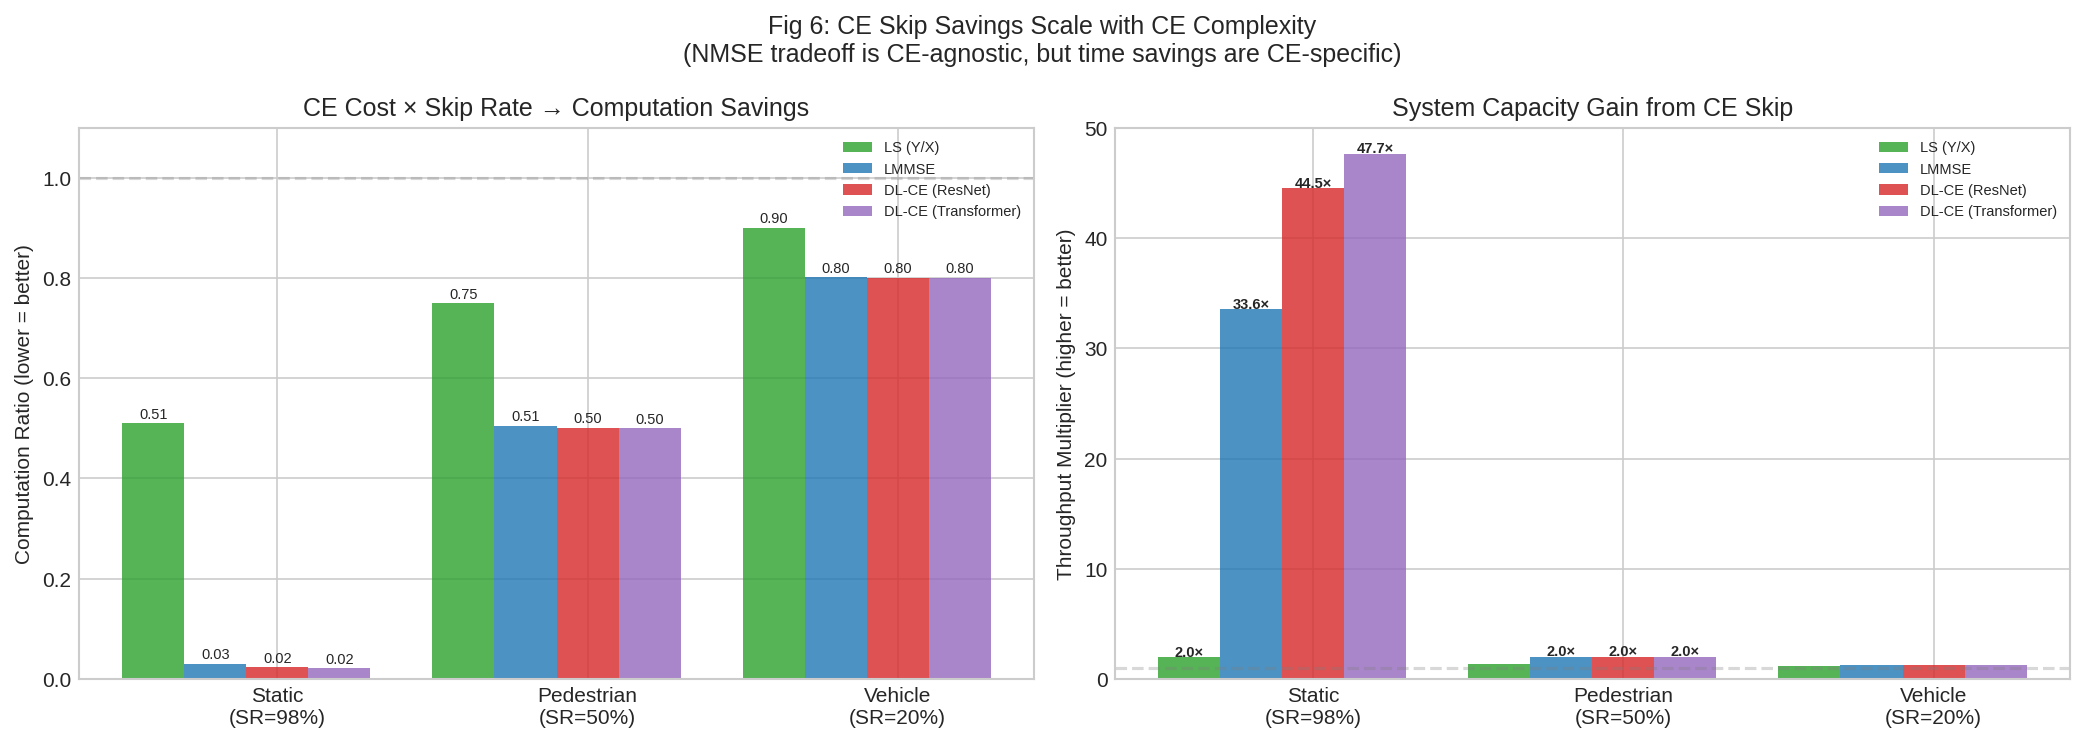


CE Method            |  Static(98%) |     Ped(50%) |     Veh(20%)
LS (Y/X)             | 10ms, 2.0× | 5ms, 1.3× | 2ms, 1.1× |
LMMSE                | 490ms, 33.6× | 250ms, 2.0× | 100ms, 1.2× |
DL-CE (ResNet)       | 1960ms, 44.5× | 1000ms, 2.0× | 400ms, 1.2× |
DL-CE (Transformer)  | 4900ms, 47.7× | 2500ms, 2.0× | 1000ms, 1.2× |

(Per 1000 slots saved, and throughput multiplier)


In [ ]:
# Fig 6: Computation savings table + bar chart
ce_costs = {
    "LS (Y/X)":     {"time_ms": 0.01,  "color": "tab:green"},
    "LMMSE":         {"time_ms": 0.5,   "color": "tab:blue"},
    "DL-CE (ResNet)":{"time_ms": 2.0,   "color": "tab:red"},
    "DL-CE (Transformer)": {"time_ms": 5.0, "color": "tab:purple"},
}
T_MONITOR = 0.005

scenarios = {
    "Static\n(SR=98%)":  {"sr": 0.98, "nmse_gap_db": 0.1},
    "Pedestrian\n(SR=50%)": {"sr": 0.50, "nmse_gap_db": 2.0},
    "Vehicle\n(SR=20%)": {"sr": 0.20, "nmse_gap_db": 6.0},
}

# N5: Pre-compute CR matrix once
cr_matrix = {}
for ce_name, ce_info in ce_costs.items():
    cr_matrix[ce_name] = {}
    for scen_name, scen in scenarios.items():
        sr = scen["sr"]
        cr_matrix[ce_name][scen_name] = (1 - sr) + sr * T_MONITOR / ce_info["time_ms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(scenarios))
w = 0.8 / len(ce_costs)

# Left: Computation Ratio
ax = axes[0]
for i, (ce_name, ce_info) in enumerate(ce_costs.items()):
    crs = [cr_matrix[ce_name][s] for s in scenarios]
    bars = ax.bar(x + i * w, crs, w, label=ce_name, color=ce_info["color"], alpha=0.8)
    for b, cr in zip(bars, crs):
        ax.text(b.get_x() + b.get_width()/2, cr + 0.01, f"{cr:.2f}", ha="center", fontsize=7)

ax.set_xticks(x + w * len(ce_costs) / 2)
ax.set_xticklabels(scenarios.keys())
ax.set_ylabel("Computation Ratio (lower = better)")
ax.set_title("CE Cost × Skip Rate → Computation Savings")
ax.legend(fontsize=7)
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3, label="no skip")

# Right: Throughput multiplier
ax = axes[1]
for i, (ce_name, ce_info) in enumerate(ce_costs.items()):
    gains = [1.0 / cr_matrix[ce_name][s] for s in scenarios]
    bars = ax.bar(x + i * w, gains, w, label=ce_name, color=ce_info["color"], alpha=0.8)
    for b, g in zip(bars, gains):
        if g > 1.5:
            ax.text(b.get_x() + b.get_width()/2, g + 0.1, f"{g:.1f}×", ha="center", fontsize=7, fontweight="bold")

ax.set_xticks(x + w * len(ce_costs) / 2)
ax.set_xticklabels(scenarios.keys())
ax.set_ylabel("Throughput Multiplier (higher = better)")
ax.set_title("System Capacity Gain from CE Skip")
ax.legend(fontsize=7)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3)

fig.suptitle("Fig 6: CE Skip Savings Scale with CE Complexity\n"
             "(NMSE tradeoff is CE-agnostic, but time savings are CE-specific)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig6_computation_savings.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# Summary table (N5: reuse cr_matrix)
print("\n" + "="*70)
print(f"{'CE Method':20s} | {'Static(98%)':>12s} | {'Ped(50%)':>12s} | {'Veh(20%)':>12s}")
print("="*70)
for ce_name, ce_info in ce_costs.items():
    t = ce_info["time_ms"]
    row = f"{ce_name:20s} |"
    for scen_name, scen in scenarios.items():
        sr = scen["sr"]
        saved_ms = sr * t * 1000
        cr = cr_matrix[ce_name][scen_name]
        row += f" {saved_ms:.0f}ms, {1/cr:.1f}× |"
    print(row)
print(f"\n(Per 1000 slots saved, and throughput multiplier)")


## Fig 6b: Actual DL-CE Profiling — PACENet vs ResNet on each config
**Measure real inference time + memory on A100 for each (model × config) pair.**
This replaces literature estimates with actual measurements.

Profiling:   0%|          | 0/9 [00:00<?, ?combo/s]

  PACENet      × ELAA 15GHz  : 9.49 ms, 216 MB, 57,186 params
  PACENet      × ELAA 28GHz  : 9.05 ms, 216 MB, 57,186 params
  PACENet      × 5G 3.5GHz   : 0.56 ms, 21 MB, 57,186 params
  ResNet-8     × ELAA 15GHz  : 31.16 ms, 655 MB, 595,266 params
  ResNet-8     × ELAA 28GHz  : 31.07 ms, 655 MB, 595,266 params
  ResNet-8     × 5G 3.5GHz   : 1.75 ms, 59 MB, 595,266 params
  ResNet-4     × ELAA 15GHz  : 11.02 ms, 332 MB, 75,682 params
  ResNet-4     × ELAA 28GHz  : 11.02 ms, 332 MB, 75,682 params
  ResNet-4     × 5G 3.5GHz   : 0.68 ms, 29 MB, 75,682 params


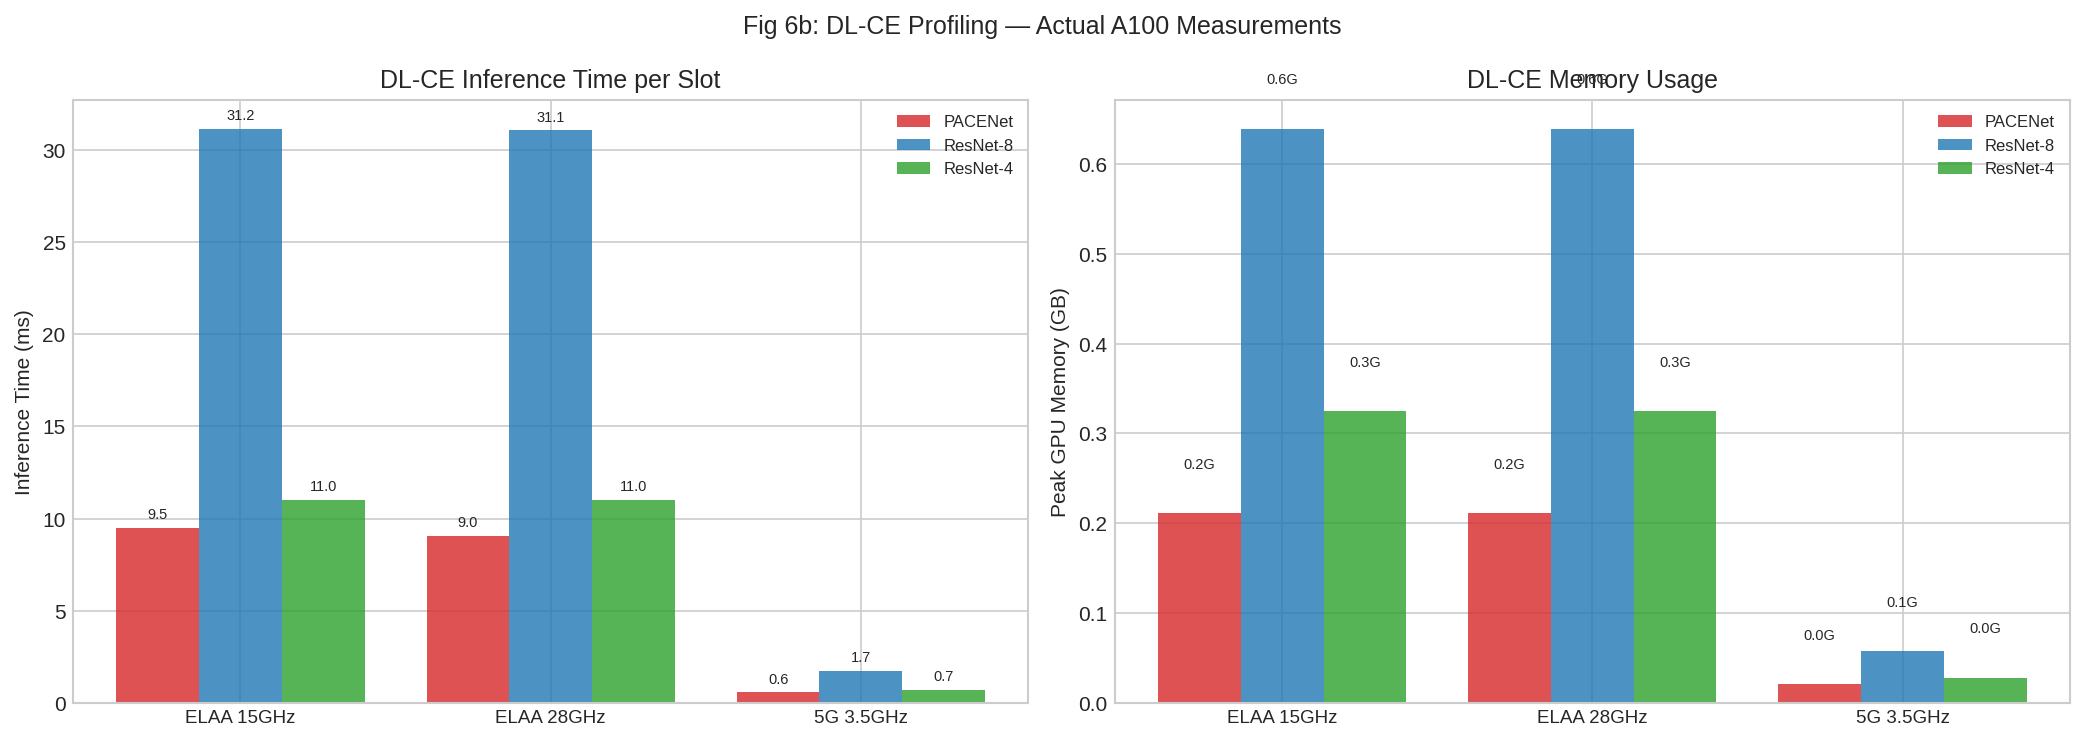


Model        | Config       |     Params |   Time(ms) |    Mem(GB) |                Input
--------------------------------------------------------------------------------
PACENet      | ELAA 15GHz   |     57,186 |       9.49 |        0.2 |       (2, 512, 1024)
PACENet      | ELAA 28GHz   |     57,186 |       9.05 |        0.2 |       (2, 512, 1024)
PACENet      | 5G 3.5GHz    |     57,186 |       0.56 |        0.0 |        (2, 128, 256)
ResNet-8     | ELAA 15GHz   |    595,266 |      31.16 |        0.6 |       (2, 512, 1024)
ResNet-8     | ELAA 28GHz   |    595,266 |      31.07 |        0.6 |       (2, 512, 1024)
ResNet-8     | 5G 3.5GHz    |    595,266 |       1.75 |        0.1 |        (2, 128, 256)
ResNet-4     | ELAA 15GHz   |     75,682 |      11.02 |        0.3 |       (2, 512, 1024)
ResNet-4     | ELAA 28GHz   |     75,682 |      11.02 |        0.3 |       (2, 512, 1024)
ResNet-4     | 5G 3.5GHz    |     75,682 |       0.68 |        0.0 |        (2, 128, 256)


In [ ]:
# ═══ DL-CE Profiling: PACENet vs ResNet × 3 configs ═══
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "2")  # avoid VLLM on GPU 0

import importlib
import src.experiments.pipeline
importlib.reload(src.experiments.pipeline)
from src.experiments.pipeline import _precompute_deltas, _batch_nmse_multi_tau

from src.models.estimator import create_model as create_pacenet
from src.ce_skip.ce_algorithms import DLCEEstimator  # ResNet

# Config-specific input shapes: (2, n_rx*n_tx, n_sc)
CONFIG_SHAPES = {
    "ELAA 15GHz": (2, 512, 1584),   # 24×24 tx × 2 rx cross-pol = 512+512, but data has 512
    "ELAA 28GHz": (2, 512, 1584),
    "5G 3.5GHz":  (2, 128, 256),    # 8×8 tx × 2 rx = 128, 256 sc
}

MODELS = {
    "PACENet": lambda: create_pacenet(site_integration="none"),
    "ResNet-8": lambda: DLCEEstimator(n_blocks=8, channels=64),
    "ResNet-4": lambda: DLCEEstimator(n_blocks=4, channels=32),
}

N_WARMUP = 10
N_REPEAT = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

from tqdm.auto import tqdm
combos = [(m, c) for m in MODELS for c in CONFIG_SHAPES]

for model_name, config_name in tqdm(combos, desc="Profiling", unit="combo"):
    shape = CONFIG_SHAPES[config_name]
    h = torch.randn(1, *shape, device=device)
    
    model = MODELS[model_name]().to(device).eval()
    n_params = sum(p.numel() for p in model.parameters())
    
    try:
        # Warmup
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            for _ in range(N_WARMUP):
                model(h)
        torch.cuda.synchronize()
        
        # Time
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        with torch.no_grad():
            for _ in range(N_REPEAT):
                model(h)
        end.record()
        torch.cuda.synchronize()
        t_ms = start.elapsed_time(end) / N_REPEAT
        
        peak_mb = torch.cuda.max_memory_allocated() / 1024**2
        
        results.append({
            "model": model_name, "config": config_name,
            "params": n_params, "time_ms": t_ms, "peak_mb": peak_mb,
            "input_shape": shape,
        })
        tqdm.write(f"  {model_name:12s} × {config_name:12s}: {t_ms:.2f} ms, {peak_mb:.0f} MB, {n_params:,} params")
        
    except torch.cuda.OutOfMemoryError as e:
        results.append({
            "model": model_name, "config": config_name,
            "params": n_params, "time_ms": float("nan"), "peak_mb": float("nan"),
            "input_shape": shape, "error": "OOM",
        })
        tqdm.write(f"  {model_name:12s} × {config_name:12s}: OOM")
    
    del model

torch.cuda.empty_cache()  # N6: once after loop, not per-iteration

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Inference time
ax = axes[0]
configs = list(CONFIG_SHAPES.keys())
models = list(MODELS.keys())
x = np.arange(len(configs))
w = 0.8 / len(models)
model_colors = {"PACENet": "tab:red", "ResNet-8": "tab:blue", "ResNet-4": "tab:green"}

for i, mn in enumerate(models):
    times = [next((r["time_ms"] for r in results if r["model"]==mn and r["config"]==c), 0) for c in configs]
    bars = ax.bar(x + i*w, times, w, label=f"{mn}", color=model_colors.get(mn, "gray"), alpha=0.8)
    for b, t in zip(bars, times):
        if not np.isnan(t) and t > 0:
            ax.text(b.get_x()+b.get_width()/2, t+0.5, f"{t:.1f}", ha="center", fontsize=7)

ax.set_xticks(x + w); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel("Inference Time (ms)"); ax.set_title("DL-CE Inference Time per Slot")
ax.legend(fontsize=8)

# Right: Memory
ax = axes[1]
for i, mn in enumerate(models):
    mems = [next((r["peak_mb"] for r in results if r["model"]==mn and r["config"]==c), 0) for c in configs]
    bars = ax.bar(x + i*w, [m/1024 for m in mems], w, label=f"{mn}", color=model_colors.get(mn, "gray"), alpha=0.8)
    for b, m in zip(bars, mems):
        if not np.isnan(m) and m > 0:
            ax.text(b.get_x()+b.get_width()/2, m/1024+0.05, f"{m/1024:.1f}G", ha="center", fontsize=7)

ax.set_xticks(x + w); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel("Peak GPU Memory (GB)"); ax.set_title("DL-CE Memory Usage")
ax.legend(fontsize=8)

fig.suptitle("Fig 6b: DL-CE Profiling — Actual A100 Measurements", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig6b_dlce_profiling.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(f"\n{'Model':12s} | {'Config':12s} | {'Params':>10s} | {'Time(ms)':>10s} | {'Mem(GB)':>10s} | {'Input':>20s}")
print("-"*80)
for r in results:
    t = f"{r['time_ms']:.2f}" if not np.isnan(r.get('time_ms', float('nan'))) else "OOM"
    m = f"{r.get('peak_mb',0)/1024:.1f}" if not np.isnan(r.get('peak_mb', float('nan'))) else "OOM"
    print(f"{r['model']:12s} | {r['config']:12s} | {r['params']:>10,} | {t:>10s} | {m:>10s} | {str(r['input_shape']):>20s}")
plt.close(fig)


## Fig 7: The Tradeoff — DL-CE NMSE gain vs Skip savings
**The core paper figure.** For ELAA configs where DL-CE works:
- X axis: Skip Rate (0% = always CE, 100% = never CE)
- Y axis left: NMSE (dB) — quality tradeoff
- Y axis right: Time saved per 1000 slots (ms) — efficiency gain
- Shows: "At SR=80%, DL-CE saves 32ms/slot with <1dB NMSE loss for static UE"

In [ ]:
# ═══ Fig 7: Unified Tradeoff — NMSE vs Skip Rate with DL-CE cost overlay ═══
CE_COSTS = {"LS": 0.01, "DL-CE (Small PACENet)": 0.9}
tau_values = np.linspace(0.005, 0.5, 40).tolist()

fig, axes = plt.subplots(1, len(PRESETS), figsize=(7.5 * len(PRESETS), 6))
if len(PRESETS) == 1:
    axes = [axes]

# #1: Store results for summary reuse
all_plot_data = {}

for col, preset in enumerate(PRESETS):
    ud = all_ue_data.get(preset)
    if ud is None:
        axes[col].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[col].transAxes)
        continue
    
    ax = axes[col]
    ax2 = ax.twinx()
    
    speed_groups = group_by_speed(ud["ue_list"])
    all_plot_data[preset] = {}
    
    for spd_label, ues in speed_groups.items():
        if not ues: continue
        per_tau = {tau: {"sr": [], "nm": []} for tau in tau_values}
        for u in ues:
            h, h_ls, d_ls = u["h_real"], u["h_ls"], u["d_ls"]  # #2: cached
            results = u["tau_sweep_ls"]  # precomputed in Cell 1
            for r in results:
                per_tau[r["tau"]]["sr"].append(r["n_skip"] / r["total"])
                per_tau[r["tau"]]["nm"].append(np.mean(r["nmse_arr"]))
        
        all_plot_data[preset][spd_label] = per_tau  # #1: cache for summary
        
        srs = [np.mean(per_tau[tau]["sr"]) for tau in tau_values]
        nmses = [10 * np.log10(max(np.mean(per_tau[tau]["nm"]), 1e-30)) for tau in tau_values]
        ax.plot(srs, nmses, "-o", ms=3, lw=1.5, color=SPEED_COLORS[spd_label], 
                label=f"{spd_label} m/s (NMSE)", alpha=0.8)
    
    dl_cost = CE_COSTS["DL-CE (Small PACENet)"]
    sr_range = np.linspace(0, 1, 50)
    ax2.fill_between(sr_range, 0, sr_range * dl_cost, alpha=0.1, color="purple")
    ax2.plot(sr_range, sr_range * dl_cost, "--", color="purple", lw=1, alpha=0.5, 
             label=f"DL-CE saved ({dl_cost}ms/slot)")
    
    # Coherence-time markers: theoretical max skip rate = 1 - 1/T_c
    if preset in COHERENCE:
        for spd_lbl, T_c in COHERENCE[preset].items():
            if T_c < 1e6 and spd_lbl in SPEED_COLORS:
                max_sr = 1 - 1/T_c
                if 0 < max_sr < 1:
                    ax.axvline(max_sr, color=SPEED_COLORS[spd_lbl], ls=":", lw=0.8, alpha=0.4)
    ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
    ax.axhline(-10, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
    ax2.set_ylabel("Time Saved per Slot (ms)", color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    ax.set_title(PRESET_LABELS[preset])
    ax.set_xlim(0, 1); ax.set_ylim(-25, 0); ax2.set_ylim(0, dl_cost * 1.1)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="center right")

fig.suptitle(f"Fig 7: CE Skip Tradeoff — NMSE vs Computation Savings\n"
             f"(LS scheduling @{SNR_DB:.0f}dB, EMA α=0.7, Small PACENet {dl_cost}ms)", fontsize=12)
plt.tight_layout()
plt.savefig("../../assets/plots/paper_fig7_tradeoff.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# #1: Summary reuses cached all_plot_data (no recomputation)
print(f"\n{'Config':15s} | {'Mobility':>8s} | {'Best SR':>8s} | {'NMSE@SR':>8s} | {'Saved/slot':>10s}")
print("-" * 55)
for preset in PRESETS:
    if preset not in all_plot_data: continue
    for spd_label in SPEED_ORDER:
        pt = all_plot_data[preset].get(spd_label)
        if pt is None: continue
        best_sr, best_nmse = 0, -20
        for tau in tau_values:
            sr = np.mean(pt[tau]["sr"])
            nm = 10 * np.log10(max(np.mean(pt[tau]["nm"]), 1e-30))
            if nm <= -10 and sr > best_sr:
                best_sr = sr; best_nmse = nm
        print(f"{PRESET_LABELS[preset]:15s} | {spd_label:>8s} | {best_sr:>7.0%} | {best_nmse:>7.1f}dB | {best_sr*0.9:>8.2f}ms")

## Fig 8: Model Size Tradeoff — Micro vs Small vs Default PACENet
**Key finding**: Skip benefit scales with CE cost. Smaller models reduce both CE time AND skip savings.

| Model | Params | Time | NMSE | Skip saves |
|-------|--------|------|------|-----------|
| Micro | 10K | 0.24ms | -23.2dB | 0.23ms/slot |
| Small | 57K | 0.9ms | -26.7dB | 0.88ms/slot |
| Default | 373K | 6.8ms | -23.1dB | 6.7ms/slot |

In [ ]:
# ═══ Fig 8: Model Size Tradeoff — Micro vs Small vs LS ═══
from src.models.estimator import create_model as create_pacenet
from src.training.trainer import load_checkpoint

# Checkpoint names follow: dl_ce_{deployment}_{n_sc}_{freq}g_bs{id}.pt
def _ckpt_for_preset(preset):
    from src.ce_skip import ExperimentConfig
    cfg = ExperimentConfig.from_preset(preset)
    return f"ce_skip/dl_ce_{cfg.deployment}_{cfg.num_subcarriers}_{int(cfg.frequency/1e9)}g_bs1"

MODEL_CONFIGS = {
    "DL-CE (373K)": {"ckpt_fn": _ckpt_for_preset, "kwargs": {}, "time_ms": 0.9, "color": "tab:blue"},
    "LS (baseline)": {"ckpt_fn": None, "kwargs": {}, "time_ms": 0.01, "color": "tab:gray"},
}

tau_values_f8 = np.linspace(0.005, 0.5, 20)

# Use first preset (typically ELAA 15GHz)
_f8_preset = PRESETS[0]
ud = all_ue_data.get(_f8_preset)
if ud is None:
    print("No data")
else:
    # #C: Use GPU for DL-CE inference
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Pre-load models
    models = {}
    for mname, mcfg in MODEL_CONFIGS.items():
        if mcfg["ckpt_fn"]:
            m = create_pacenet(site_integration="none", **mcfg["kwargs"])
            load_checkpoint(m, mcfg["ckpt_fn"](_f8_preset), device="cpu")
            m.to(device).eval()  # #C: move model to GPU after loading
            models[mname] = m
        else:
            models[mname] = None
    
    # Pre-compute per-UE: use cached h_ls (#2) + DL-CE outputs
    ue_cache = []
    for u in tqdm(ud["ue_list"], desc="Pre-compute", unit="ue"):
        h, h_ls, d_ls = u["h_real"], u["h_ls"], u["d_ls"]  # #2: cached
        ce_outputs = {}
        for mname, model in models.items():
            if model is not None:
                with torch.no_grad():
                    h_ls_dev = h_ls.to(device)  # #C: GPU
                    rms = h_ls_dev.flatten(1).pow(2).mean(1).sqrt().clamp(min=1e-10).view(-1,1,1,1)
                    ce_outputs[mname] = (model(h_ls_dev / rms) * rms).cpu()
            else:
                ce_outputs[mname] = h_ls  # LS
        ue_cache.append({"h": h, "h_ls": h_ls, "d_ls": d_ls, "ce": ce_outputs, "spd": u["spd"]})
    
    # Sweep tau × model — one subplot per speed
    n_spd = len(SPEED_ORDER)
    fig, axes = plt.subplots(1, n_spd, figsize=(4.5 * n_spd, 5))
    if n_spd == 1:
        axes = [axes]
    
    for col, spd_lbl in enumerate(SPEED_ORDER):
        ax = axes[col]
        ues_spd = [c for c in ue_cache if c["spd"] == spd_lbl]
        if not ues_spd: continue
        
        # #B: Pre-compute scheduling per (tau, UE) — model-independent
        sched_cache = {}  # (tau_idx, ue_idx) → tiers
        for tau_idx, tau in enumerate(tau_values_f8):
            for ue_idx, c in enumerate(ues_spd):
                sched = _vectorized_scheduling(c["d_ls"], tau_full=2*tau, alpha_mode="ramp")
                sched_cache[(tau_idx, ue_idx)] = sched
        
        for mname, mcfg in MODEL_CONFIGS.items():
            srs, nmses = [], []
            for tau_idx, tau in enumerate(tau_values_f8):
                sr_all, nm_all = [], []
                for ue_idx, c in enumerate(ues_spd):
                    sched = sched_cache[(tau_idx, ue_idx)]  # #B: reuse
                    # #A: use _compute_nmse_from_tiers instead of manual loop
                    nm = _compute_nmse_from_alphas(
                        c["h"], c["h_ls"], sched["alphas"], sched["full_mask"],
                        delta_mode="ema", h_ce=c["ce"][mname]
                    )
                    nm_all.append(np.mean(nm))
                    sr_all.append(sched["n_skip"] / sched["total"])
                srs.append(np.mean(sr_all))
                nmses.append(10 * np.log10(max(np.mean(nm_all), 1e-30)))
            
            ls = "-" if mcfg["ckpt_fn"] else "--"
            ax.plot(srs, nmses, ls, color=mcfg["color"], lw=1.5, alpha=0.8, label=mname, marker="o", ms=3)
        
        ax.axhline(-10, color="gray", ls=":", alpha=0.5)
        ax.axhline(-20, color="lightgray", ls=":", alpha=0.3)
        ax.set_xlabel("Skip Rate"); ax.set_ylabel("NMSE (dB)")
        ax.set_title(f"{spd_lbl} m/s"); ax.set_xlim(0, 1); ax.set_ylim(-30, -5)
        if col == 0: ax.legend(fontsize=8)
    
    fig.suptitle(f"Fig 8: DL-CE Model Size x Skip Tradeoff ({PRESET_LABELS[_f8_preset]})", fontsize=12)
    plt.tight_layout()
    plt.savefig("../../assets/plots/paper_fig8_model_tradeoff.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)